# PyTheraTwin Pipeline — Output Analysis

## Quick Start
1. Set `OUTPUT_TITLE` in the **User Config** cell below and run it.
2. Run **Imports** (cell 1) and **Setup** (cell 2).
3. Run whichever section cells you want. Each visualization cell checks its `SHOW_*` flag — set the flag `True` in Setup to enable that section.

In [407]:
# ── Edit here, then run this cell ────────────────────────────────────────────
OUTPUT_TITLE = 'paper_dataset'
OUTPUT_ROOT  = '/home/jhubadmin/Theranostic-Virtual-Patient-Pipeline'
CT_DIR       = '/home/jhubadmin/Theranostic-Virtual-Patient-Pipeline/inputs/testing_dataset'

print(f'Target: {OUTPUT_ROOT}/{OUTPUT_TITLE}')


Target: /home/jhubadmin/Theranostic-Virtual-Patient-Pipeline/paper_dataset


## 1 — Imports and Helpers

In [408]:
import os, re, json, math, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import SimpleITK as sitk
from scipy.optimize import curve_fit, OptimizeWarning

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.titleweight': 'bold',
    'axes.labelsize': 16,
    'axes.labelweight': 'bold',
    'figure.titlesize': 20,
    'figure.titleweight': 'bold',
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


def _strip_comments(text):
    lines = []
    for line in text.splitlines():
        idx = line.find('//')
        lines.append(line[:idx] if idx >= 0 else line)
    return '\n'.join(lines)

def load_json(path):
    with open(path, encoding='utf-8') as f:
        return json.loads(_strip_comments(f.read()))

def list_files(directory, suffix):
    if not os.path.isdir(directory):
        return []
    return sorted(os.path.join(directory, f) for f in os.listdir(directory) if f.endswith(suffix))

def stem(path):
    name = os.path.basename(path)
    return name[:-7] if name.endswith('.nii.gz') else os.path.splitext(name)[0]

def fmt_int(v):
    try: return f'{int(v):,}'
    except: return str(v)

def pct(numer, denom, eps=1e-9):
    return (numer - denom) / (abs(denom) + eps) * 100.0

def safe_name(text):
    name = re.sub(r'[^A-Za-z0-9_.-]+', '_', str(text)).strip('_')
    return name or 'plot'

def finish_plot(fig, name, tight=True):
    if tight:
        try: fig.tight_layout()
        except: pass
    _add_title_underlines(fig)
    if globals().get('SAVE_PLOTS', False):
        out_dir = Path(globals().get('PLOT_OUTPUT_DIR', 'notebook_plots'))
        out_dir.mkdir(parents=True, exist_ok=True)
        for ext in globals().get('PLOT_FORMATS', ('png',)):
            out_path = out_dir / f'{safe_name(name)}.{ext}'
            fig.savefig(out_path, dpi=globals().get('PLOT_DPI', 200), bbox_inches='tight')
            if globals().get('PRINT_SAVED_PLOTS', True):
                print('Saved:', out_path)
    if globals().get('SHOW_PLOTS', True):
        plt.show()
    else:
        plt.close(fig)

def plot_spec(section, key, default=None):
    return globals().get('PLOT_SPECS', {}).get(section, {}).get(key, default)

def med_aspect(sp_row_mm, sp_col_mm):
    """Physical aspect ratio for imshow: height-per-pixel / width-per-pixel."""
    return float(sp_row_mm) / float(sp_col_mm)

def optimal_grid(n, max_cols=None):
    """Return (nrows, ncols) minimising empty panels, preferring landscape."""
    if n <= 0: return 1, 1
    ub = min(max_cols, n) if max_cols else n
    best_nc, best_nr, best_score = 1, n, float('inf')
    for nc in range(1, ub + 1):
        nr = math.ceil(n / nc)
        waste = nr * nc - n
        portrait_pen = max(0, nr - nc) * 500  # strongly prefer landscape
        aspect_pen   = abs(nc / nr - 1.0) * 50
        score = waste * 200 + portrait_pen + aspect_pen
        if score < best_score:
            best_score = score
            best_nc, best_nr = nc, nr
    return best_nr, best_nc

def make_grid(n, max_cols=None, pw=5.0, ph=5.0):
    if n <= 0: return None, None, 0, 0
    nr, nc = optimal_grid(n, max_cols=max_cols)
    fig, axes = plt.subplots(nr, nc, figsize=(pw*nc, ph*nr), squeeze=False)
    return fig, axes, nr, nc

def _add_title_underlines(fig):
    """Draw a thin rule beneath every subplot title."""
    try:
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        fw = fig.get_figwidth() * fig.dpi
        fh = fig.get_figheight() * fig.dpi
        for ax in fig.axes:
            t = ax.title
            if not t.get_text(): continue
            bb = t.get_window_extent(renderer=renderer)
            x0, x1 = bb.x0 / fw, bb.x1 / fw
            y = (bb.y0 - 2) / fh
            line = plt.Line2D([x0, x1], [y, y], transform=fig.transFigure,
                              color=t.get_color(), linewidth=0.8, clip_on=False)
            fig.add_artist(line)
    except Exception:
        pass

def fmt_roi_label(roi, patient_idx=None):
    """Display name for an ROI. Synthetic lesions show organ + count from config."""
    if roi.lower().startswith('synthetic_lesion_'):
        suffix = roi.lower()[len('synthetic_lesion_'):]  # e.g. 'tumor1', 'tumorrest'
        confs = globals().get('configs', {})
        if patient_idx is not None and patient_idx in confs:
            specs = confs[patient_idx].get('phase_1', {}).get('synthetic_lesions_stage', {}).get('specs', {})
            for organ, s in specs.items():
                if s.get('pbpk_label', '').lower() == suffix:
                    n_les = s.get('n_lesions', 1)
                    return f'Synthetic Lesion: Tumor in {organ.title()} × {n_les}'
        num = ''.join(c for c in suffix if c.isdigit())
        return f'Synthetic Lesion: Tumor {num}' if num else 'Synthetic Lesion: Tumor'
    return roi.replace('_', ' ').title()

def fmt_roi_label_with_vol(roi, i, display_label=None):
    """Return 'Label : X.X mL' using stored mask volume if available."""
    base = display_label if display_label is not None else fmt_roi_label(roi, i)
    vol = globals().get('mask_volume_store', {}).get(i, {}).get(
        (roi or '').lower(), {}).get('volume_ml')
    if vol is not None:
        return f'{base} : {vol:.1f} mL'
    return base

def add_colorbar(fig, ax, im, label='', shrink=0.85):
    if globals().get('SHOW_COLORBARS', True):
        cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=shrink)
        if label: cb.set_label(label, fontsize=13)
        cb.ax.tick_params(labelsize=12)
        return cb

def select_frame_labels(labels, mode='all', selected=None):
    ls = sorted([str(x) for x in labels], key=lambda k: float(k))
    sel = [] if selected is None else [str(x) for x in selected]
    if not ls: return []
    if mode == 'first': return ls[:1]
    if mode == 'last': return ls[-1:]
    if mode == 'selected':
        want = {str(float(x)).rstrip('0').rstrip('.') for x in sel}
        return [l for l in ls if str(float(l)).rstrip('0').rstrip('.') in want]
    return ls

def normalize_unit(u):
    u = str(u).lower().strip()
    if u not in {'mm','cm'}: raise ValueError(f'Unknown unit {u}')
    return u

def unit_scale_factor(fu, tu):
    fu, tu = normalize_unit(fu), normalize_unit(tu)
    if fu == tu: return 1.0
    if fu == 'mm' and tu == 'cm': return 0.1
    if fu == 'cm' and tu == 'mm': return 10.0
    raise ValueError

def scale_img_units(img, fu, tu):
    f = unit_scale_factor(fu, tu)
    if f == 1.0: return sitk.Image(img)
    out = sitk.Image(img)
    out.SetSpacing((np.array(out.GetSpacing())*f).tolist())
    out.SetOrigin((np.array(out.GetOrigin())*f).tolist())
    return out

def voxel_volume_ml(spacing, unit):
    unit = normalize_unit(unit)
    vol = float(np.prod(np.asarray(spacing, dtype=float)))
    return vol if unit == 'cm' else vol / 1000.0

def comparison_xlim(frame_hr):
    manual = globals().get('COMPARISON_XLIM_HR', 'frame_range')
    if isinstance(manual, (tuple, list)) and len(manual)==2:
        return tuple(float(v) for v in manual)
    if manual == 'full': return None
    fh = np.asarray(frame_hr, dtype=float)
    fh = fh[np.isfinite(fh)]
    if fh.size == 0: return None
    return (0.0, max(1.0, float(fh.max())*1.10))

def nanmean_std_count(values, axis=0):
    arr = np.asarray(values, dtype=float)
    finite = np.isfinite(arr)
    count = np.sum(finite, axis=axis)
    summed = np.sum(np.where(finite, arr, 0.0), axis=axis)
    mean = np.divide(summed, count, out=np.full(np.shape(summed), np.nan, dtype=float), where=count>0)
    if axis == 0: centered = arr - mean
    elif axis == 1: centered = arr - mean[:,None]
    else: centered = arr - np.expand_dims(mean, axis=axis)
    ss = np.sum(np.where(finite, centered**2, 0.0), axis=axis)
    std = np.sqrt(np.divide(ss, count, out=np.full(np.shape(ss), np.nan, dtype=float), where=count>0))
    return mean, std, count

def nanmedian_iqr(values, axis=0):
    arr = np.asarray(values, dtype=float)
    med = np.nanmedian(arr, axis=axis)
    q1 = np.nanpercentile(arr, 25, axis=axis)
    q3 = np.nanpercentile(arr, 75, axis=axis)
    return med, q3-q1

def plot_mean_std_series(ax, x, mean, std, *, label=None, color=None, marker='o', lw=2.0):
    x, mean, std = np.asarray(x,float), np.asarray(mean,float), np.asarray(std,float)
    mask = np.isfinite(x) & np.isfinite(mean)
    if not np.any(mask): return None
    xp, yp = x[mask], mean[mask]
    sp = np.where(np.isfinite(std[mask]), std[mask], 0.0)
    if xp.size == 1:
        return ax.errorbar(xp, yp, yerr=sp, fmt=marker, ms=7, capsize=4, color=color, label=label)
    (line,) = ax.plot(xp, yp, marker=marker, lw=lw, color=color, label=label)
    bc = color if color is not None else line.get_color()
    ax.fill_between(xp, yp-sp, yp+sp, color=bc, alpha=0.18, linewidth=0)
    return line

def fmt_num(v, width=12, precision=3):
    return f'{v:{width}.{precision}f}' if np.isfinite(v) else f"{'n/a':>{width}s}"

def fmt_pct(v, width=10, precision=1):
    return f'{v:+{width}.{precision}f}%' if np.isfinite(v) else f"{'n/a':>{width}s}"

def fmt_mean_std(mean, std, width=20, precision=3):
    if not np.isfinite(mean): return f"{'n/a':>{width}s}"
    s = f'{std:.{precision}f}' if np.isfinite(std) else 'n/a'
    return f'{mean:.{precision}f}+/-{s}' .rjust(width)

def _resolve_out_folders():
    """Rebuild OUT_FOLDERS from OUTPUT_ROOT/OUTPUT_TITLE if not set."""
    if 'OUT_FOLDERS' in globals(): return globals()['OUT_FOLDERS']
    root = globals().get('OUTPUT_ROOT','')
    title = globals().get('OUTPUT_TITLE','')
    project = os.path.join(root, title)
    def idx(n):
        m = re.search(r'CT_(\d+)', n)
        return int(m.group(1)) if m else 10**9
    return sorted(
        [os.path.join(project, d) for d in os.listdir(project)
         if os.path.isdir(os.path.join(project, d)) and d.startswith('CT_')],
        key=lambda p: idx(os.path.basename(p))
    ) if os.path.isdir(project) else []

def get_slice(arr, axis=1, mode=None):
    """Return a 2D coronal view: 'mid'=centre slice, 'max'=max-intensity projection."""
    if (mode or 'mid').lower() == 'max':
        return np.max(arr, axis=axis)
    return np.take(arr, arr.shape[axis] // 2, axis=axis)

def ct_label(i):
    """Display label for patient i, using actual folder CT number after any patient filter."""
    folders = globals().get('OUT_FOLDERS') or _resolve_out_folders()
    if 0 <= i < len(folders):
        name = os.path.basename(folders[i])
        try: return f"CT {int(name.replace('CT_','',1))}"
        except: return name
    return f'CT {i+1}'
print('Imports OK')


Imports OK


## 2 — Setup and Plot Specs
Edit flags here. Set `SHOW_*` to `True` to enable that section's plots.

In [409]:
# ── Paths (inherit from User Config) ──────────────────────────────────────────
SAVE_PLOTS       = False
PLOT_OUTPUT_DIR  = str(Path(OUTPUT_ROOT) / 'figures' / 'output_analysis' / OUTPUT_TITLE)
PLOT_FORMATS     = ('png',)
PLOT_DPI         = 200
PRINT_SAVED_PLOTS = True
SHOW_PLOTS       = True
SHOW_COLORBARS   = True

PLOT_PATIENTS    = 11  # None = all; int or list of CT numbers to include (e.g. 3 or [1,3,5])

# ── Section show/hide flags ────────────────────────────────────────────────────
# inital outputs
SHOW_CT           = True
SHOW_SEGMENTATION = True
SHOW_LESIONS      = True
SHOW_PBPK         = True
SHOW_SIMIND_MAPS  = True
SHOW_SIMIND_PROJ  = True
SHOW_OPENGATE     = True
SHOW_ROI_ACTIVITY = True
SHOW_SPECT        = True
SHOW_DOSE         = True
SHOW_DOSE_SUMMARY = True

#comparison flags
SHOW_MASK_OVERLAY = True
SHOW_COMPARISON   = True
SHOW_FITTING      = True
SHOW_AUC          = True
SHOW_PROFILE      = False

# ── Image display ─────────────────────────────────────────────────────────────
CT_WINDOW           = (-200, 200) # HU range for CT display (soft tissue)
SLICE_MODE          = 'mid'       # global: 'mid' = coronal mid-slice | 'max' = max-intensity projection
CT_SLICE_MODE       = None        # per-section override (None → uses SLICE_MODE)
SEG_SLICE_MODE      = None
OPENGATE_SLICE_MODE = None
ROI_ACT_SLICE_MODE  = None
DOSE_SLICE_MODE     = None
SPECT_VIEW_AXIS  = 'coronal'     # 'axial', 'coronal', or 'sagittal' for SPECT recon view
DOSE_SUM_VIEW_AXIS = 'coronal'   # 'axial', 'coronal', or 'sagittal' for 6d dose-sum view
SPECT_SHARED_SCALE = True
SIMIND_ANGLE     = 0              # Projection angle index to display in 6b
SIMIND_FRAME_HR  = None           # Frame time (hr) to display in 6b; None = first available

# ── Colormaps ─────────────────────────────────────────────────────────────────
PLOT_SPECS = {
    'ct':           {'cmap': 'gray'},
    'segmentation': {'cmap': 'tab20'},
    'lesions':      {'cmap': 'hot'},
    'pbpk':         {'colors': ['#1f77b4','#d62728','#2ca02c','#9467bd','#8c564b','#e377c2','#17becf','#bcbd22']},
    'simind':       {'atn_cmap':'gray','activity_cmap':'inferno','projection_cmap':'hot'},
    'opengate':     {'cmap':'plasma'},
    'spect':        {'cmap':'hot','percentile':99.5},
    'activity':     {'cmap':'hot'},
    'dose':         {'cmap':'plasma','percentile':99.0},
    'mask':         {'image_cmap':'hot','contour_color':'cyan'},
    'comparison':   {'pbpk_color':'steelblue','spect_color':'orangered'},
    'profile':      {'cmap':'tab10'},
}

# ── PBPK / SPECT ──────────────────────────────────────────────────────────────
PBPK_XLIM_HR        = (0, 24)     # TAC x-axis range (hours); None = full range
PBPK_Y_SCALE        = 'linear'
SPECT_FRAME_MODE    = 'all'       # 'all', 'first', 'last', or 'selected'
SPECT_SELECTED_FRAMES = []
SPECT_RECON_SPACING_UNIT   = 'mm'
DOSE_UNC_VMAX_PCT          = 10   # uncertainty colour-scale ceiling (%) e.g. 50 → shows 0–50%
SEGMENTATION_SPACING_UNIT  = 'mm'

# ── Comparison controls ───────────────────────────────────────────────────────
COMPARE_ONLY_SIMULATED_ROIS       = True
INCLUDE_REMAINING_BODY_IN_COMPARISON = True
SKIP_ROIS_COMPARISON              = {}
SKIP_LAST_FRAME                   = False
COMPARISON_XLIM_HR                = 'frame_range'
COMPARISON_EXCLUDE_ROIS           = []    # e.g. ['liver'] — exclude from 9a/9b
COMPARISON_EXCLUDE_FRAMES         = []    # e.g. [168] — exclude frame times (hr)
COMPARISON_ERROR_LIMIT_PCT        = 100  # clip y-axis of % error; e.g. 150 = ±150%
FIT_MAX_PBPK_POINTS               = 2000
FITTING_XLIM_HR                   = 24    # visual x-limit for plot only (hr); fitting always uses full PBPK range
FIT_XLIM_FACTOR                   = 1.15  # x-axis = max_spect_frame * this factor

# ── Profiling ─────────────────────────────────────────────────────────────────
PROFILE_PHASE = ''
PARAM_LABEL   = 'Patient'
STAGE_ORDER   = ['segmentation','synthetic_lesions','pbpk_tac','simind','opengate','spect_postprocess','dosemap_postprocess']

print('Setup loaded')
print(f'  OUTPUT_TITLE = {OUTPUT_TITLE}')
print(f'  OUTPUT_ROOT  = {OUTPUT_ROOT}')


Setup loaded
  OUTPUT_TITLE = paper_dataset
  OUTPUT_ROOT  = /home/jhubadmin/Theranostic-Virtual-Patient-Pipeline


## 3 — Discover Output Folders and Stage Inventory

In [410]:
PROJECT_DIR = os.path.join(OUTPUT_ROOT, OUTPUT_TITLE)

def ct_index_from_name(name):
    try: return int(name.replace('CT_','',1))
    except: return 10**9

def discover_ct_inputs(ct_dir):
    ct_inputs = []
    if os.path.isdir(ct_dir):
        for entry in sorted(os.listdir(ct_dir)):
            p = os.path.join(ct_dir, entry)
            if os.path.isdir(p) or entry.endswith(('.nii','.nii.gz')):
                ct_inputs.append(p)
    return ct_inputs

def recorded_ct_for_folder(folder):
    meta_path = os.path.join(folder, 'pipeline_metadata', 'ct_input.json')
    if not os.path.exists(meta_path): return None
    try:
        meta = load_json(meta_path)
        identity = meta.get('ct_identity', {})
        return identity.get('current_input_path') or identity.get('saved_copy_path')
    except: return None

folder_names = sorted(
    [d for d in (os.listdir(PROJECT_DIR) if os.path.isdir(PROJECT_DIR) else [])
     if os.path.isdir(os.path.join(PROJECT_DIR, d)) and d.startswith('CT_')],
    key=lambda n: (ct_index_from_name(n), n),
)
OUT_FOLDERS = [os.path.join(PROJECT_DIR, d) for d in folder_names]

# ── PLOT_PATIENTS filter ─────────────────────────────────────────────────
_pt_raw = globals().get('PLOT_PATIENTS', None)
if _pt_raw is not None:
    _pt_set = {_pt_raw} if isinstance(_pt_raw, int) else set(_pt_raw)
    _all_nums = {ct_index_from_name(os.path.basename(f)) for f in OUT_FOLDERS}
    for p in sorted(_pt_set - _all_nums):
        print(f'PLOT_PATIENTS: CT {p} — N/A (not found in output folder)')
    OUT_FOLDERS = [f for f in OUT_FOLDERS
                   if ct_index_from_name(os.path.basename(f)) in _pt_set]

N = len(OUT_FOLDERS)
ct_inputs = discover_ct_inputs(CT_DIR)

if N == 0:
    print(f'No CT_* folders found in {PROJECT_DIR}')
else:
    print(f'Found {N} output folder(s):')
    for i, f in enumerate(OUT_FOLDERS):
        recorded_ct = recorded_ct_for_folder(f)
        fallback_ct = ct_inputs[i] if i < len(ct_inputs) else None
        ct_str = recorded_ct or fallback_ct or '(unknown)'
        source = 'metadata' if recorded_ct else 'input-order fallback'
        print(f'  {ct_label(i)}: {os.path.basename(f)} <- {os.path.basename(str(ct_str))} [{source}]')


Found 1 output folder(s):
  CT 11: CT_11 <- CT_11.nii.gz [metadata]


In [411]:
EXPECTED_OUTPUTS = [
    ('Input CT',         ['digital_twin/ct.nii.gz']),
    ('Segmentation',     ['digital_twin/digital_twin.nii.gz']),
    ('Synthetic lesions',['digital_twin/synthetic_lesions_stage/synthetic_lesions_all_lesions_labels.nii.gz']),
    ('PBPK TAC',         ['digital_twin/pbpk_tac_stage/pbpk_tacs.npz']),
    ('SIMIND',           ['simulations/simind_tot_w1.a00']),
    ('OpenGATE',         ['pipeline_metadata/opengate_simulation_stage.json']),
    ('SPECT recon',      ['post_processing/reconstructed_SPECT_*.nii.gz']),
    ('Dose map',         ['post_processing/dosemap_postprocess_total_dose.nii.gz']),
    ('Profiling',        ['profiling_CT_*.json']),
]

def pattern_exists(folder, pattern):
    return bool(list(Path(folder).glob(pattern)))

inventory_store = {}
for i, folder in enumerate(OUT_FOLDERS):
    rows = []
    for stage, patterns in EXPECTED_OUTPUTS:
        hits = [p for p in patterns if pattern_exists(folder, p)]
        rows.append({'stage': stage, 'present': bool(hits), 'missing': [p for p in patterns if p not in hits]})
    inventory_store[i] = rows
    print(f'\n{ct_label(i)}: {os.path.basename(folder)}')
    for row in rows:
        icon = '✓' if row['present'] else '✗'
        print(f'  {icon} {row["stage"]}')



CT 11: CT_11
  ✓ Input CT
  ✓ Segmentation
  ✓ Synthetic lesions
  ✓ PBPK TAC
  ✓ SIMIND
  ✓ OpenGATE
  ✓ SPECT recon
  ✓ Dose map
  ✓ Profiling


## 4 — Configuration Summary

In [412]:
configs = {}
for i, folder in enumerate(OUT_FOLDERS):
    cfg_path = os.path.join(folder, 'config.json')
    if os.path.exists(cfg_path):
        configs[i] = load_json(cfg_path)

    print('='*72)
    print(f'  {ct_label(i)}: {os.path.basename(folder)}')
    print('='*72)
    if i not in configs:
        print('  config.json not found'); continue

    cfg = configs[i]
    p1 = cfg.get('phase_1', {}); p2 = cfg.get('phase_2', {}); p3 = cfg.get('phase_3', {})
    seg = p1.get('segmentation_stage',{}); les = p1.get('synthetic_lesions_stage',{})
    pbpk = p1.get('pbpk_tac_stage',{}); sim = p2.get('simind_stage',{})
    og = p2.get('opengate_stage',{}); spect = p3.get('spect_postprocess_stage',{})
    dose = p3.get('dosemap_postprocess_stage',{})

    print('\n  Phase 1: Digital twin')
    print(f'    ROIs: {seg.get("roi_subset",[])}')
    specs = les.get('specs',{})
    if specs:
        for organ, s in specs.items():
            print(f'    Lesions: {organ} — {s.get("n_lesions",0)} lesion(s), radii={s.get("radii_mm")} mm')
    else:
        print('    Lesions: none')
    print(f'    PBPK: model={pbpk.get("model_type","-")}  isotope={pbpk.get("isotope","-")}')

    print('\n  Phase 2: Simulations')
    print(f'    SIMIND: isotope={sim.get("isotope","-")}  collimator={sim.get("Collimator","-")}')
    print(f'      photons={fmt_int(sim.get("NumPhotons","-"))}  projections={sim.get("NumProjections","-")}')
    print(f'    OpenGATE: histories={fmt_int(og.get("gate",{}).get("total_histories","-"))}')

    print('\n  Phase 3: Post-processing')
    ft = sorted(spect.get('FrameStartTimes',[]))
    fd = spect.get('FrameDurations',[])
    ft_hr = [f'{t/60:.1f}h' for t in ft]
    print(f'    SPECT frames: {len(ft)} — {ft_hr}')
    print(f'    Reconstruction: {spect.get("ReconstructionAlgorithm","-")}  iter={spect.get("Iterations","-")}  subsets={spect.get("Subsets","-")}')
print()


  CT 11: CT_11

  Phase 1: Digital twin
    ROIs: ['kidney', 'liver', 'prostate', 'spleen', 'heart', 'salivary_glands', 'lungs', 'brain', 'adrenal_glands', 'thyroid_gland', 'gallbladder', 'gi_tract', 'pancreas', 'esophagus', 'trachea', 'urinary_bladder', 'kidney_cyst', 'bone', 'spinal_cord', 'aorta', 'pulmonary_vein', 'brachiocephalic_vessels', 'carotid_arteries', 'portal_vein', 'iliac_arteries', 'iliac_veins', 'atrial_appendage', 'superior_vena_cava', 'inferior_vena_cava', 'muscle', 'eyes', 'eye_lenses', 'optic_nerves', 'nasopharynx', 'oropharynx', 'hypopharynx', 'nasal_cavity', 'auditory_canal', 'soft_palate', 'hard_palate']
    Lesions: liver — 1 lesion(s), radii=[5] mm
    PBPK: model=PSMA  isotope=lu177

  Phase 2: Simulations
    SIMIND: isotope=lu177  collimator=si-me
      photons=1,000,000,000  projections=96
    OpenGATE: histories=-

  Phase 3: Post-processing
    SPECT frames: 12 — ['1.0h', '2.0h', '3.0h', '8.0h', '12.0h', '24.0h', '48.0h', '72.0h', '96.0h', '120.0h', '144.

## 5 — Phase 1: Digital Twin Outputs

### 5a — Input CT

CT 11  shape=(254,400,400)  spacing=(2.04,2.04,3.00) mm


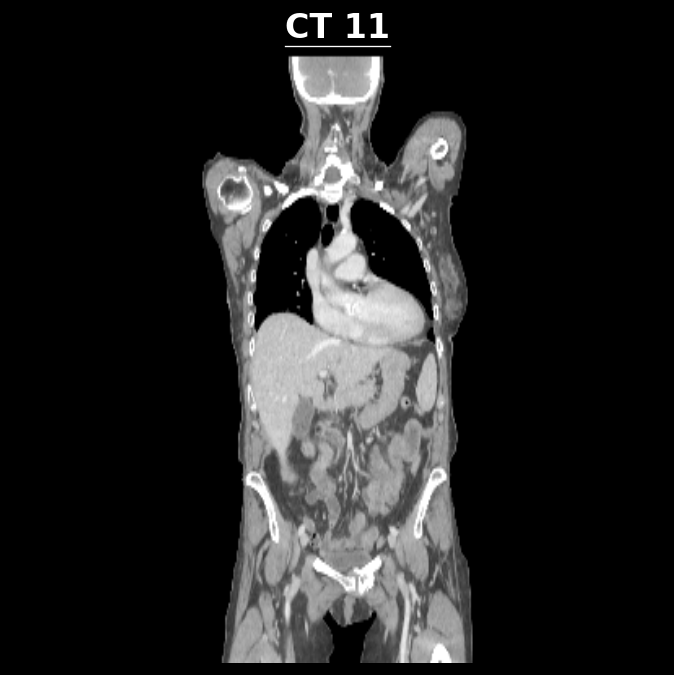

In [413]:
if not globals().get('SHOW_CT', False):
    print('5a CT skipped — set SHOW_CT = True in Setup')
else:
    _folders = _resolve_out_folders()
    for i, folder in enumerate(_folders):
        ct_path = os.path.join(folder, 'digital_twin', 'ct.nii.gz')
        if not os.path.exists(ct_path):
            print(f'{ct_label(i)}: ct.nii.gz not found'); continue

        img = sitk.ReadImage(ct_path)
        arr = sitk.GetArrayFromImage(img)[::-1]   # z,y,x head-up
        sp  = img.GetSpacing()                     # x,y,z mm
        sp_x, sp_y, sp_z = sp
        z, y, x = arr.shape
        print(f'{ct_label(i)}  shape=({z},{y},{x})  spacing=({sp_x:.2f},{sp_y:.2f},{sp_z:.2f}) mm')

        vmin, vmax_ct = globals().get('CT_WINDOW', (-200, 200))

        _mode = globals().get('CT_SLICE_MODE') or globals().get('SLICE_MODE', 'mid')
        sl = get_slice(arr, axis=1, mode=_mode)
        asp = med_aspect(sp_z, sp_x)
        phys_w = x * sp_x
        phys_h = z * sp_z
        fig_w = 7
        fig_h = max(3.0, fig_w * phys_h / phys_w)

        fig, ax = plt.subplots(figsize=(fig_w, fig_w))
        fig.patch.set_facecolor('black')
        ax.set_facecolor('black')
        ax.imshow(sl, cmap='gray', vmin=vmin, vmax=vmax_ct, interpolation='bilinear', aspect=asp)
        ax.axis('off')
        ax.set_title(f'{ct_label(i)}', color='white', fontsize=20, pad=10)
        finish_plot(fig, f'ct_{i+1}_input_ct', tight=False)


### 5b — PyTheraTwin Segmentation

CT 11  labels: {1: 'remaining_body', 2: 'kidney', 3: 'liver', 5: 'spleen', 6: 'heart', 7: 'salivary_glands', 9: 'lungs', 10: 'adrenal_glands', 11: 'thyroid_gland', 12: 'gallbladder', 14: 'pancreas', 15: 'esophagus', 16: 'trachea', 20: 'urinary_bladder', 21: 'brain', 22: 'kidney_cyst', 24: 'spinal_cord', 27: 'aorta', 28: 'pulmonary_vein', 29: 'brachiocephalic_vessels', 30: 'carotid_arteries', 31: 'portal_vein', 32: 'iliac_arteries', 33: 'iliac_veins', 34: 'atrial_appendage', 35: 'superior_vena_cava', 36: 'inferior_vena_cava', 47: 'eyes', 48: 'eye_lenses', 49: 'optic_nerves', 50: 'nasopharynx', 51: 'oropharynx', 52: 'hypopharynx', 53: 'nasal_cavity', 54: 'auditory_canal', 55: 'soft_palate', 56: 'hard_palate', 57: 'gi_tract', 58: 'bone', 59: 'muscle', 60: 'synthetic_lesion_tumor2'}


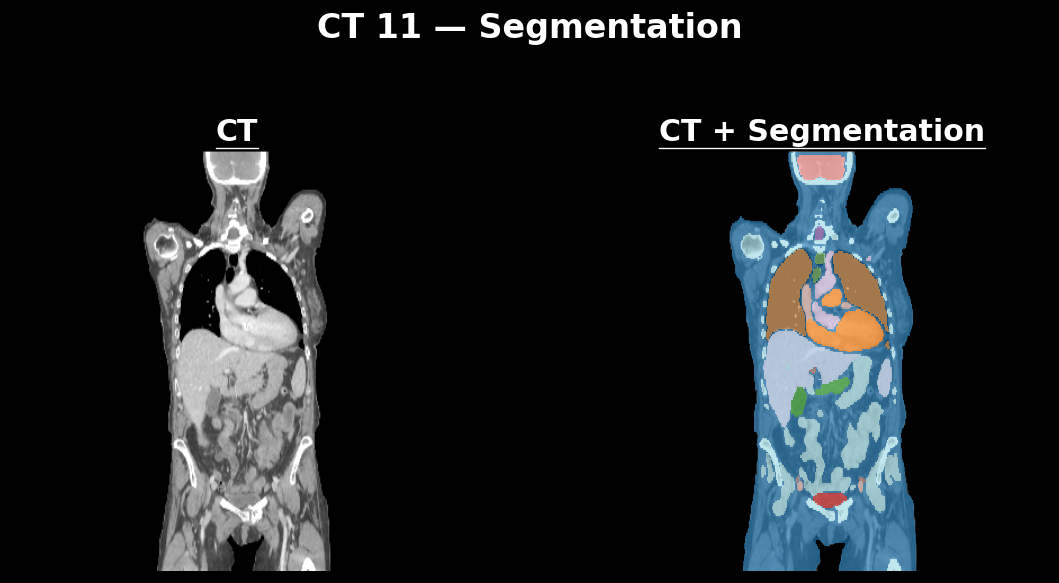

In [414]:
if not globals().get('SHOW_SEGMENTATION', False):
    print('5b Segmentation skipped — set SHOW_SEGMENTATION = True in Setup')
else:
    _folders = _resolve_out_folders()
    roi_map_path = str(Path(OUTPUT_ROOT) / 'src' / 'data' / 'pipeline_roi_naming_map.json')
    label_to_roi = {}
    if os.path.exists(roi_map_path):
        roi_map = load_json(roi_map_path)
        label_to_roi = {int(k): v.lower() for k,v in roi_map.get('PyTheraTwin_Pipeline',{}).items()}

    for i, folder in enumerate(_folders):
        ct_path  = os.path.join(folder, 'digital_twin', 'ct.nii.gz')
        seg_path = os.path.join(folder, 'digital_twin', 'digital_twin.nii.gz')
        if not os.path.exists(seg_path):
            print(f'{ct_label(i)}: digital_twin.nii.gz not found'); continue

        seg_img = sitk.ReadImage(seg_path)
        seg     = sitk.GetArrayFromImage(seg_img)[::-1]
        sp      = seg_img.GetSpacing()
        sp_x, sp_y, sp_z = sp
        labels  = [int(v) for v in np.unique(seg) if v != 0]
        names   = [label_to_roi.get(l, str(l)) for l in labels]
        print(f'{ct_label(i)}  labels: {dict(zip(labels, names))}')

        z, y, x = seg.shape
        _mode = globals().get('SEG_SLICE_MODE') or globals().get('SLICE_MODE', 'mid')
        sl_seg = get_slice(seg, axis=1, mode=_mode)
        asp = med_aspect(sp_z, sp_x)

        # CT background if available
        ct_sl = None
        if os.path.exists(ct_path):
            ct_img = sitk.ReadImage(ct_path)
            ct_arr = sitk.GetArrayFromImage(ct_img)[::-1]
            ct_arr_r = sitk.GetArrayFromImage(
                sitk.Resample(ct_img, seg_img, sitk.Transform(), sitk.sitkLinear, 0.0)
            )[::-1]
            ct_sl = get_slice(ct_arr_r, axis=1, mode=_mode)

        phys_h = z * sp_z; phys_w = x * sp_x
        fig_w = 10; fig_h = max(3.0, fig_w * phys_h / phys_w)
        ncols = 2 if ct_sl is not None else 1
        fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 5), squeeze=False)
        fig.patch.set_facecolor('black')
        fig.suptitle(f'{ct_label(i)} — Segmentation', color='white')

        vmin_ct, vmax_ct = globals().get('CT_WINDOW', (-200, 200))
        n_labels = max(20, int(seg.max()))
        cmap_seg = plt.get_cmap(plot_spec('segmentation','cmap','tab20'))

        if ct_sl is not None:
            axes[0][0].set_facecolor('black')
            axes[0][0].imshow(ct_sl, cmap='gray', vmin=vmin_ct, vmax=vmax_ct, interpolation='bilinear', aspect=asp)
            axes[0][0].axis('off')
            axes[0][0].set_title('CT', color='white')
            ax_ov = axes[0][1]
        else:
            ax_ov = axes[0][0]

        if ct_sl is not None:
            ax_ov.imshow(ct_sl, cmap='gray', vmin=vmin_ct, vmax=vmax_ct, interpolation='bilinear', aspect=asp)
        seg_rgba = cmap_seg(sl_seg.astype(float) / n_labels)
        seg_rgba[..., 3] = np.where(sl_seg > 0, 0.65, 0.0)
        ax_ov.imshow(seg_rgba, aspect=asp, interpolation='nearest')
        ax_ov.set_facecolor('black')
        ax_ov.axis('off')
        ax_ov.set_title('CT + Segmentation', color='white')

        fig.tight_layout(rect=[0, 0, 1, 0.90])
        finish_plot(fig, f'ct_{i+1}_segmentation', tight=False)


### 5c — Synthetic Lesions

CT 11  1 lesion(s)  shape=(254,400,400)


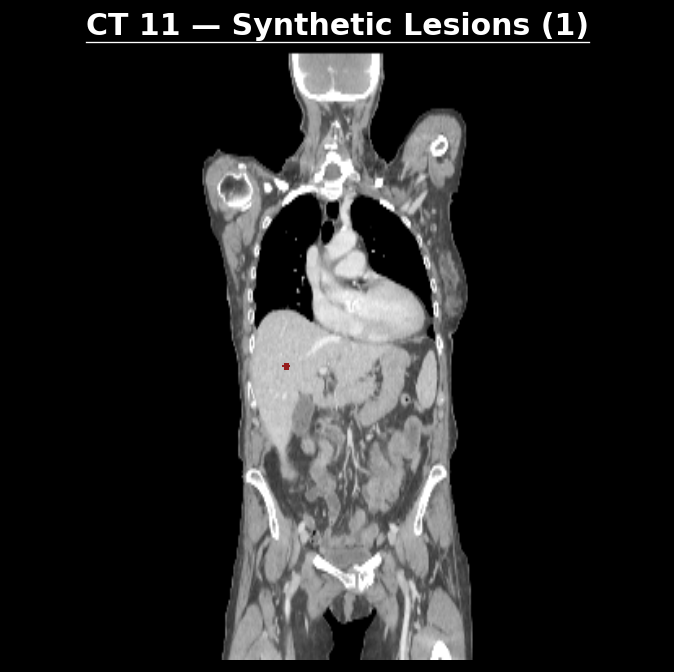

In [415]:
if not globals().get('SHOW_LESIONS', False):
    print('5c Lesions skipped — set SHOW_LESIONS = True in Setup')
else:
    _folders = _resolve_out_folders()
    for i, folder in enumerate(_folders):
        lesion_path = os.path.join(folder, 'digital_twin', 'synthetic_lesions_stage',
                                   'synthetic_lesions_all_lesions_labels.nii.gz')
        if not os.path.exists(lesion_path):
            print(f'{ct_label(i)}: no synthetic lesions'); continue

        les_img = sitk.ReadImage(lesion_path)
        les_arr = sitk.GetArrayFromImage(les_img)[::-1]
        sp      = les_img.GetSpacing()
        sp_x, sp_y, sp_z = sp
        n_lesions = int(np.max(les_arr))
        z, y, x = les_arr.shape
        print(f'{ct_label(i)}  {n_lesions} lesion(s)  shape=({z},{y},{x})')

        asp = med_aspect(sp_z, sp_x)
        phys_h = z * sp_z; phys_w = x * sp_x
        fig_w = 7; fig_h = max(3.0, fig_w * phys_h / phys_w)
        fig, ax = plt.subplots(figsize=(fig_w, fig_w))
        fig.patch.set_facecolor('black')
        ax.set_facecolor('black')

        # CT mid slice background
        ct_path = os.path.join(folder, 'digital_twin', 'ct.nii.gz')
        if os.path.exists(ct_path):
            ct_img = sitk.ReadImage(ct_path)
            ct_r = sitk.GetArrayFromImage(
                sitk.Resample(ct_img, les_img, sitk.Transform(), sitk.sitkLinear, 0.0)
            )[::-1]
            vmin_ct, vmax_ct = globals().get('CT_WINDOW', (-200, 200))
            ax.imshow(ct_r[:, y//2, :], cmap='gray', vmin=vmin_ct, vmax=vmax_ct,
                      interpolation='bilinear', aspect=asp)

        # Lesion max projection overlay (hot, alpha)
        les_mip = np.max(les_arr, axis=1).astype(float)   # coronal max proj: shape (z, x)
        les_mip_norm = np.where(les_mip > 0, les_mip / max(n_lesions, 1), np.nan)
        cmap_les = plt.get_cmap(plot_spec('lesions', 'cmap', 'hot')).copy()
        cmap_les.set_bad(alpha=0)
        ax.imshow(les_mip_norm, cmap=cmap_les, vmin=0, vmax=5, alpha=0.85,
                  interpolation='nearest', aspect=asp)
        ax.axis('off')
        ax.set_title(f'{ct_label(i)} — Synthetic Lesions ({n_lesions})', color='white', fontsize=18, pad=10)
        finish_plot(fig, f'ct_{i+1}_synthetic_lesions', tight=False)


### 5d — PBPK Time-Activity Curves

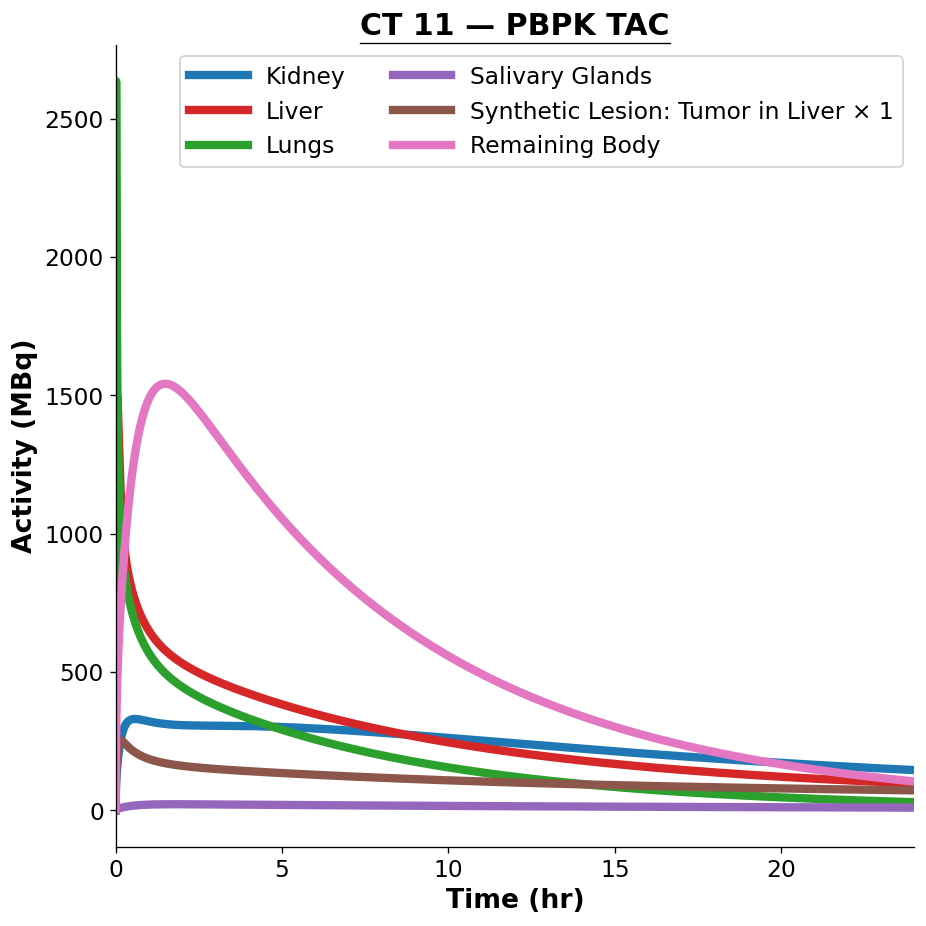

In [416]:
pbpk_store = {}
pbpk_meta_store = {}

if not globals().get('SHOW_PBPK', False):
    print('5d PBPK skipped — set SHOW_PBPK = True in Setup')
else:
    _folders = _resolve_out_folders()
    _cfgs = globals().get('configs', {})
    colors_pbpk = plot_spec('pbpk','colors',
        ['#1f77b4','#d62728','#2ca02c','#9467bd','#8c564b','#e377c2','#17becf','#bcbd22'])

    for i, folder in enumerate(_folders):
        stage_dir = os.path.join(folder, 'digital_twin', 'pbpk_tac_stage')
        npz_path  = os.path.join(stage_dir, 'pbpk_tacs.npz')
        json_path = os.path.join(stage_dir, 'pbpk_tacs.json')
        if not os.path.exists(npz_path):
            print(f'{ct_label(i)}: pbpk_tacs.npz not found'); continue

        data     = np.load(npz_path, allow_pickle=True)
        time_min = data['time'].astype(float)
        time_hr  = time_min / 60.0
        tac_rois = {k.replace('tac_',''):data[k].astype(float) for k in data.files if k.startswith('tac_')}
        pbpk_store[i] = {'time_hr': time_hr, **tac_rois}
        meta = load_json(json_path) if os.path.exists(json_path) else {}
        pbpk_meta_store[i] = meta

        xlim = globals().get('PBPK_XLIM_HR', (0, 24))
        if xlim is not None:
            mask = (time_hr >= xlim[0]) & (time_hr <= xlim[1])
        else:
            mask = np.ones(len(time_hr), dtype=bool)

        # Filter to ROIs used in SIMIND simulations (+ any synthetic lesions)
        _sim_rois_cfg = set(r.lower() for r in
            _cfgs.get(i, {}).get('phase_2', {}).get('simind_stage', {}).get('roi_subset', []))
        sim_rois = [r for r in tac_rois
                    if r.lower() in _sim_rois_cfg or r.lower().startswith('synthetic_lesion_')]
        if not sim_rois:
            sim_rois = list(tac_rois.keys())  # fallback: all
        # Always include remaining_body (once, sorted last)
        if 'remaining_body' in tac_rois and 'remaining_body' not in [r.lower() for r in sim_rois]:
            sim_rois.append('remaining_body')
        sim_rois = sorted(sim_rois, key=lambda r: (r.lower() == 'remaining_body', r))

        if xlim:
            mask = (time_hr >= xlim[0]) & (time_hr <= xlim[1])
        else:
            mask = np.ones(len(time_hr), dtype=bool)

        fig, ax = plt.subplots(figsize=(8, 8))
        for j, roi in enumerate(sim_rois):
            col = colors_pbpk[j % len(colors_pbpk)]
            ax.plot(time_hr[mask], tac_rois[roi][mask], lw=5, color=col,
                    label=fmt_roi_label(roi, i))
        if xlim: ax.set_xlim(*xlim)
        ax.set_yscale(globals().get('PBPK_Y_SCALE', 'linear'))
        ax.set_xlabel('Time (hr)')
        ax.set_ylabel('Activity (MBq)')
        ax.set_title(f'{ct_label(i)} — PBPK TAC')
        ax.legend(fontsize=14, framealpha=0.9, loc='upper right', ncol=2, handlelength=2.5)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        finish_plot(fig, f'ct_{i+1}_pbpk_tac')

# Always load PBPK data even if not plotting (needed for comparisons)
if not pbpk_store:
    _folders = _resolve_out_folders()
    for i, folder in enumerate(_folders):
        npz_path = os.path.join(folder, 'digital_twin', 'pbpk_tac_stage', 'pbpk_tacs.npz')
        json_path = os.path.join(folder, 'digital_twin', 'pbpk_tac_stage', 'pbpk_tacs.json')
        if not os.path.exists(npz_path): continue
        data = np.load(npz_path, allow_pickle=True)
        time_hr = data['time'].astype(float) / 60.0
        tac_rois = {k.replace('tac_',''):data[k].astype(float) for k in data.files if k.startswith('tac_')}
        pbpk_store[i] = {'time_hr': time_hr, **tac_rois}
        pbpk_meta_store[i] = load_json(json_path) if os.path.exists(json_path) else {}
    if pbpk_store:
        print(f'PBPK data loaded for {len(pbpk_store)} patient(s) (not plotted)')


## 6 — Phase 2: Simulation Outputs

### 6a — SIMIND Attenuation and Activity Maps

CT 11  prefix=simind  ROIs=['remaining_body', 'kidney', 'liver', 'salivary_glands', 'lungs', 'synthetic_lesion_tumor2']


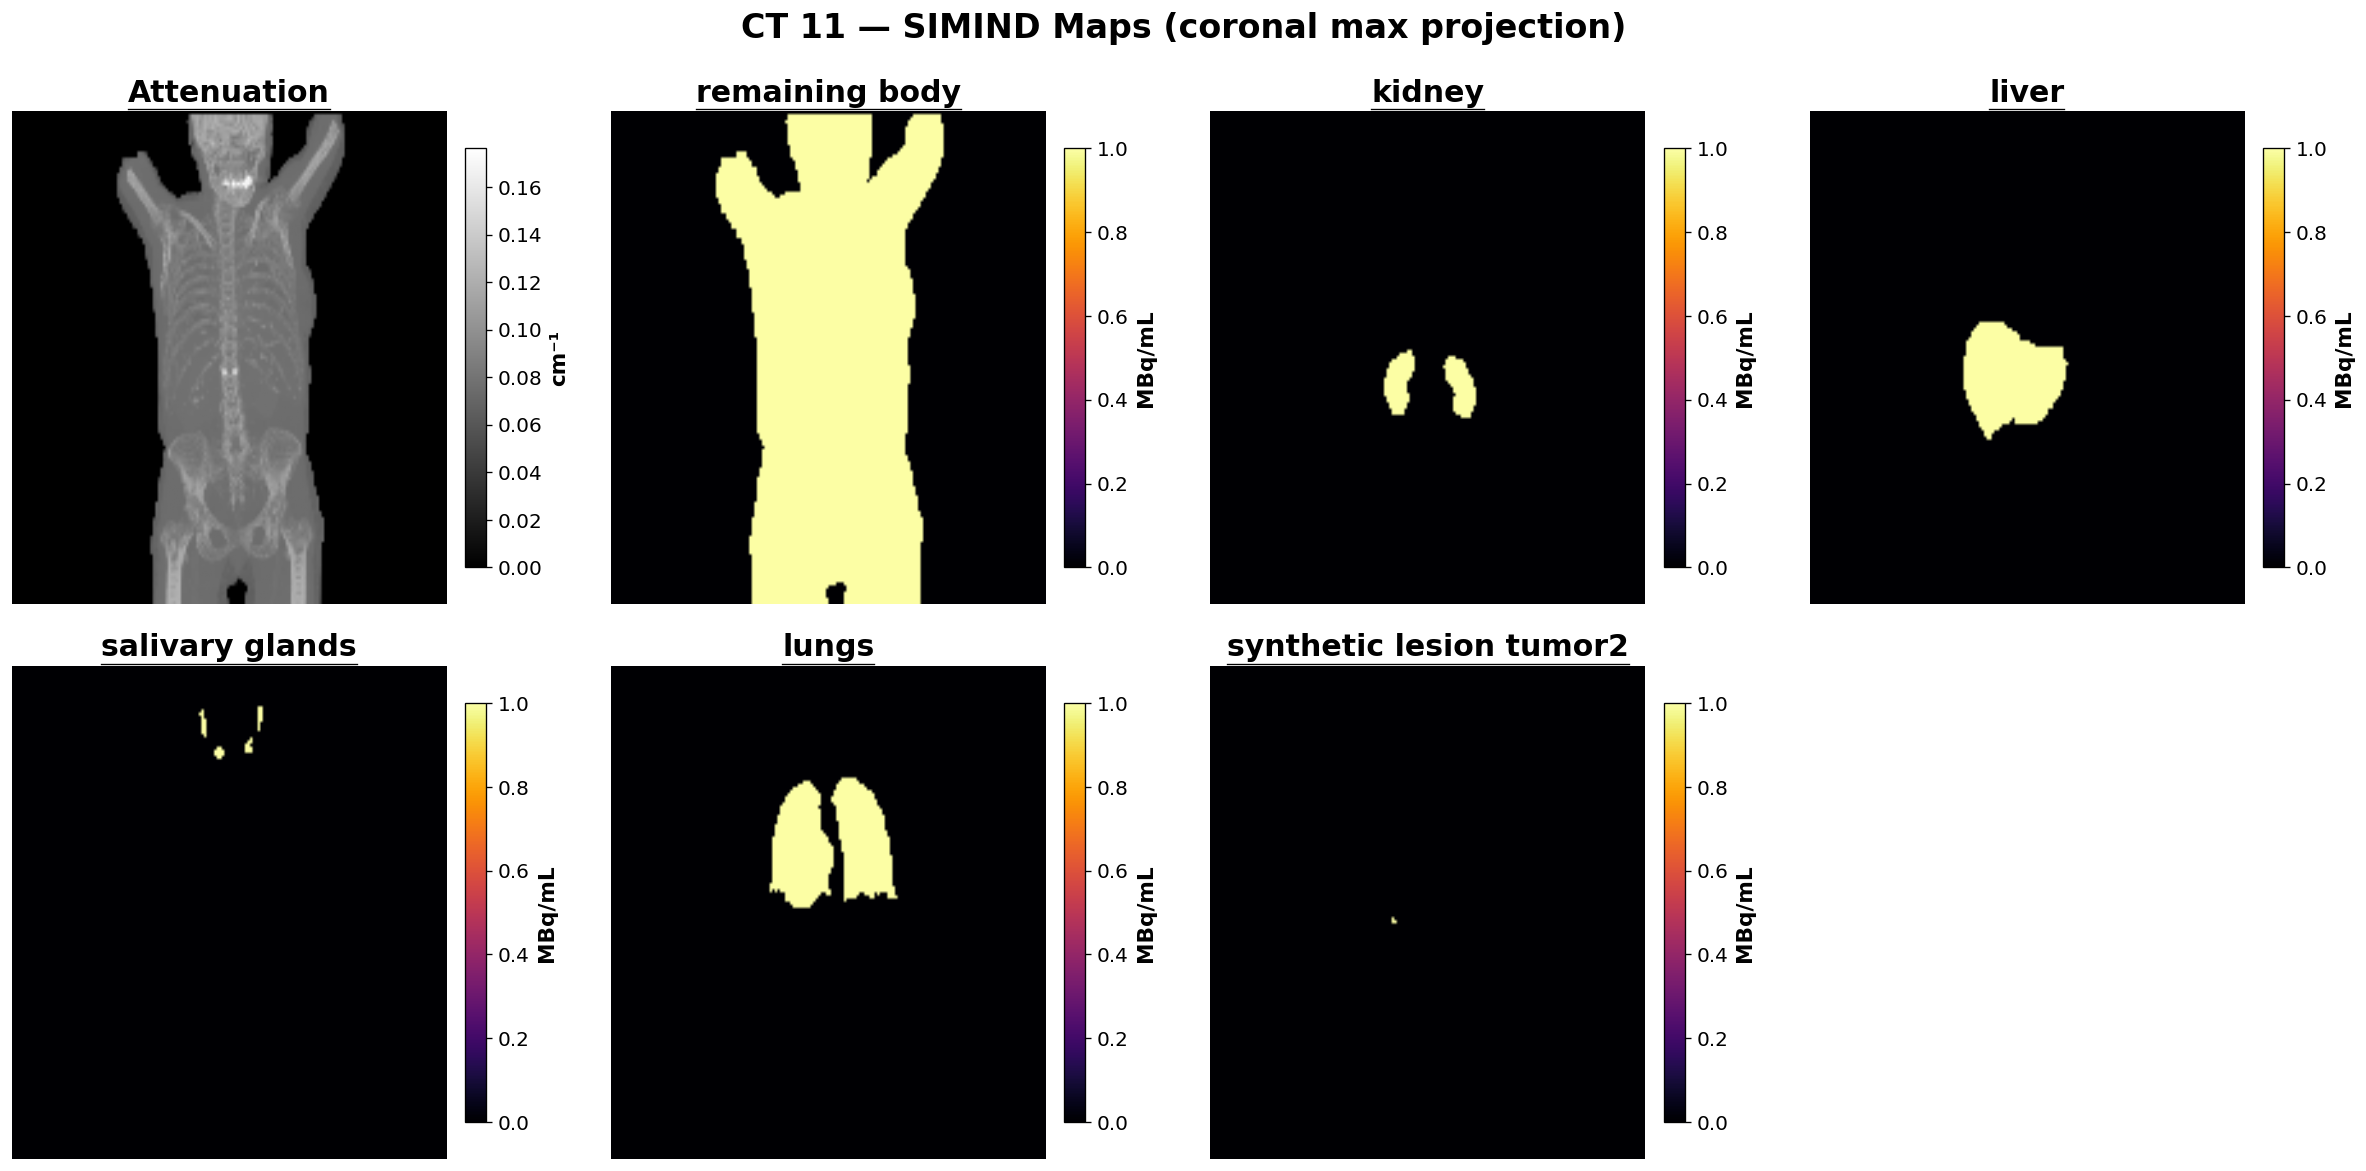

In [417]:
simind_meta_store = {}

if not globals().get('SHOW_SIMIND_MAPS', False):
    print('6a SIMIND maps skipped — set SHOW_SIMIND_MAPS = True in Setup')
else:
    _folders = _resolve_out_folders()
    for i, folder in enumerate(_folders):
        meta_path = os.path.join(folder, 'pipeline_metadata', 'simind_simulation_stage.json')
        if not os.path.exists(meta_path):
            print(f'{ct_label(i)}: SIMIND metadata not found'); continue
        m = load_json(meta_path)
        simind_meta_store[i] = m

        prefix = m.get('file_prefix', 'simind')
        roi_list = m.get('roi_list', [])
        geom = m.get('geometry', {})
        prep_dir = m.get('preprocess_dir', '')
        work_dir = m.get('work_dir', '')
        spacing = m.get('arr_px_spacing_cm', [0,0,0])
        shape_new = [int(v) for v in m.get('arr_shape_new', [0,0,0])]
        z_dim, y_dim, x_dim = shape_new if len(shape_new)==3 else (0,0,0)

        print(f'{ct_label(i)}  prefix={prefix}  ROIs={roi_list}')

        atn_flat = None
        for d in [prep_dir, work_dir]:
            p = os.path.join(d, f'{prefix}_atn_av.bin')
            if os.path.exists(p):
                atn_flat = np.fromfile(p, dtype=np.float32); break

        act_maps = {}
        act_paths = m.get('binary_roi_act_map_paths', {})
        for roi in roi_list:
            p = act_paths.get(roi, os.path.join(prep_dir, f'{prefix}_{roi}_act_av.bin'))
            if os.path.exists(p) and z_dim and y_dim and x_dim:
                flat = np.fromfile(p, dtype=np.float32)
                if flat.size == z_dim*y_dim*x_dim:
                    act_maps[roi] = flat.reshape(z_dim, y_dim, x_dim)[::-1]

        n_plots = (1 if atn_flat is not None else 0) + len(act_maps)
        if n_plots == 0:
            print(f'  {ct_label(i)}: no SIMIND binary maps found'); continue

        fig, axes, nrows, ncols = make_grid(n_plots, max_cols=4, pw=5.0, ph=5.0)
        fig.suptitle(f'{ct_label(i)} — SIMIND Maps (coronal max projection)')
        idx = 0

        if atn_flat is not None and z_dim and y_dim and x_dim and atn_flat.size==z_dim*y_dim*x_dim:
            atn = atn_flat.reshape(z_dim, y_dim, x_dim)[::-1]
            ax = axes[idx//ncols][idx%ncols]
            im = ax.imshow(np.max(atn,axis=1), cmap=plot_spec('simind','atn_cmap','gray'), aspect='auto', interpolation='bilinear')
            ax.set_title('Attenuation'); ax.axis('off')
            add_colorbar(fig, ax, im, 'cm⁻¹'); idx += 1

        for roi, arr in act_maps.items():
            ax = axes[idx//ncols][idx%ncols]
            im = ax.imshow(np.max(arr,axis=1), cmap=plot_spec('simind','activity_cmap','inferno'), aspect='auto', interpolation='bilinear')
            ax.set_title(roi.replace('_',' ')); ax.axis('off')
            add_colorbar(fig, ax, im, 'MBq/mL'); idx += 1

        for j in range(idx, nrows*ncols):
            axes[j//ncols][j%ncols].set_visible(False)
        finish_plot(fig, f'ct_{i+1}_simind_maps')

# Always load SIMIND metadata for comparisons
if not simind_meta_store:
    _folders = _resolve_out_folders()
    for i, folder in enumerate(_folders):
        p = os.path.join(folder, 'pipeline_metadata', 'simind_simulation_stage.json')
        if os.path.exists(p):
            simind_meta_store[i] = load_json(p)
    if simind_meta_store:
        print(f'SIMIND metadata loaded for {len(simind_meta_store)} patient(s)')


### 6b — SIMIND Projection Data

CT 11: showing frame=1.0h  angle_idx=0  windows=['w1', 'w2', 'w3']


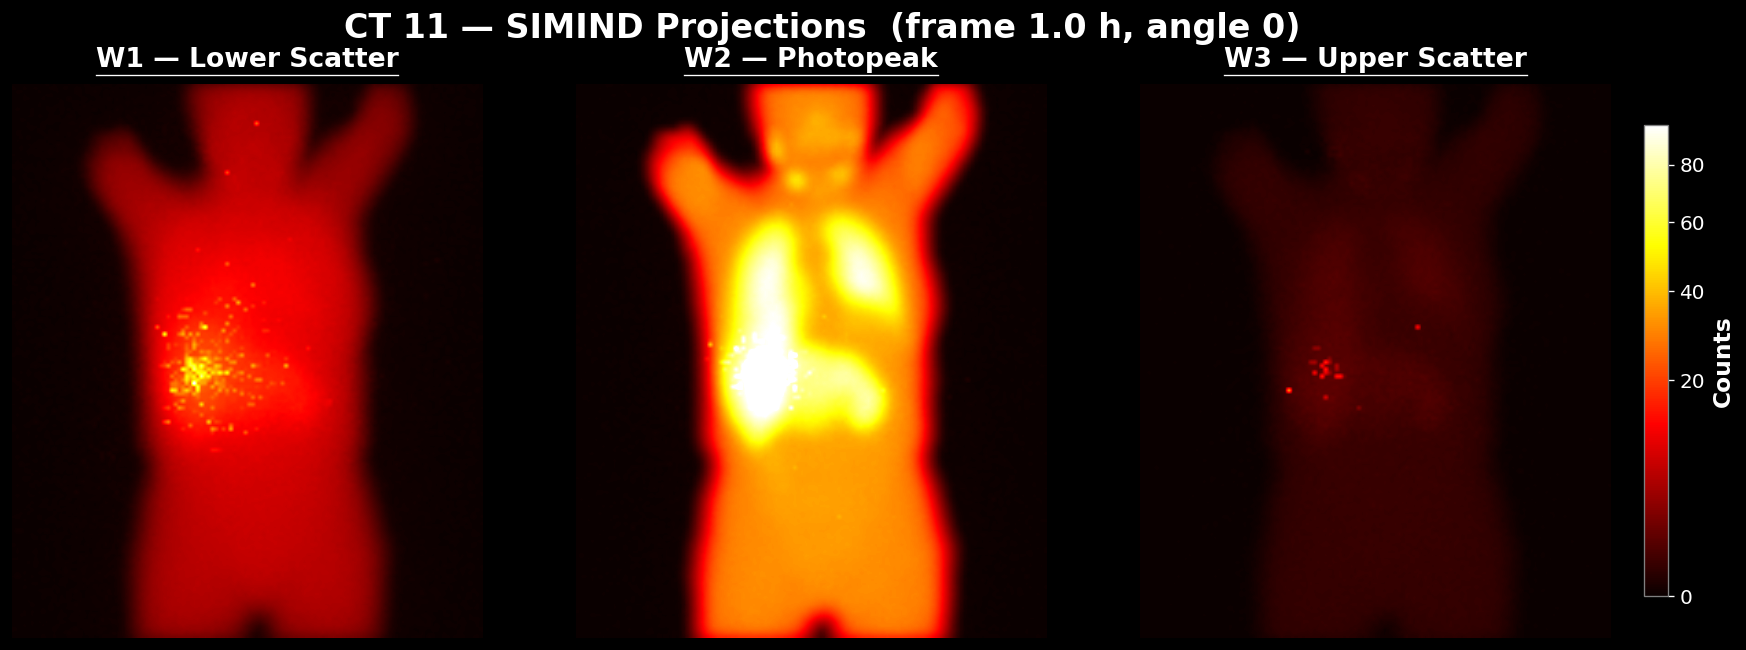

In [418]:
if not globals().get('SHOW_SIMIND_PROJ', False):
    print('6b SIMIND projections skipped — set SHOW_SIMIND_PROJ = True in Setup')
else:
    import glob as _glob

    _folders = _resolve_out_folders()
    _angle   = int(globals().get('SIMIND_ANGLE', 0))
    _want_hr = globals().get('SIMIND_FRAME_HR', None)

    def _find_proj_niftis(folder):
        """Return {frame_hr: {w: path}} dict from spect_postprocess niftis."""
        pp_dir = os.path.join(folder, 'post_processing', 'spect_postprocess')
        frames = {}
        for window in ('w1', 'w2', 'w3'):
            for p in _glob.glob(os.path.join(pp_dir, f'*_tot_{window}.nii.gz')):
                base = os.path.basename(p)
                # name pattern: prefix_<frame_hr>_tot_w?.nii.gz
                parts = base.replace(f'_tot_{window}.nii.gz','').rsplit('_', 1)
                try:
                    hr = float(parts[-1])
                except ValueError:
                    continue
                frames.setdefault(hr, {})[window] = p
        return frames

    for i, folder in enumerate(_folders):
        frame_map = _find_proj_niftis(folder)
        if not frame_map:
            print(f'{ct_label(i)}: no per-frame projection niftis found in spect_postprocess'); continue

        available_hrs = sorted(frame_map.keys())
        if _want_hr is not None and _want_hr in frame_map:
            show_hr = _want_hr
        else:
            show_hr = available_hrs[0]

        windows_avail = [w for w in ('w1','w2','w3') if w in frame_map.get(show_hr,{})]
        if not windows_avail:
            print(f'{ct_label(i)}: no w1/w2/w3 at frame {show_hr}h'); continue

        print(f'{ct_label(i)}: showing frame={show_hr}h  angle_idx={_angle}  windows={windows_avail}')

        fig, axes = plt.subplots(1, len(windows_avail), figsize=(6*len(windows_avail), 6), squeeze=False)
        fig.patch.set_facecolor('black')
        fig.suptitle(f'{ct_label(i)} — SIMIND Projections  (frame {show_hr} h, angle {_angle})',
                     color='white', fontsize=20, fontweight='bold')

        window_labels = {'w1':'W1 — Lower Scatter','w2':'W2 — Photopeak','w3':'W3 — Upper Scatter'}
        _all_imgs = []
        for w in windows_avail:
            arr3d = sitk.GetArrayFromImage(sitk.ReadImage(frame_map[show_hr][w]))
            # shape: (n_angles, h, w)
            n_ang = arr3d.shape[0]
            ang_idx = min(_angle, n_ang-1)
            img2d = np.rot90(arr3d[ang_idx])
            _all_imgs.append(img2d)

        # shared scale across windows
        _pos_vals = np.concatenate([im[im>0].ravel() for im in _all_imgs if np.any(im>0)])
        _vmax = float(np.percentile(_pos_vals, 99.5)) if _pos_vals.size else 1.0
        _norm = mcolors.PowerNorm(gamma=0.5, vmin=0, vmax=_vmax)

        for ax, w, img2d in zip(axes[0], windows_avail, _all_imgs):
            ax.set_facecolor('black')
            im = ax.imshow(img2d, cmap=plot_spec('simind','projection_cmap','hot'),
                           norm=_norm, interpolation='bilinear', aspect='auto')
            ax.axis('off')
            ax.set_title(window_labels.get(w, w), color='white', fontsize=16, pad=10)

        # shared colorbar
        cbar = fig.colorbar(im, ax=axes[0].tolist(), fraction=0.025, pad=0.02, shrink=0.85)
        cbar.set_label('Counts', color='white', fontsize=14)
        cbar.ax.tick_params(colors='white', labelsize=12)
        cbar.outline.set_edgecolor('grey')

        finish_plot(fig, f'ct_{i+1}_simind_proj_frame{show_hr}', tight=False)


### 6c — OpenGATE Dose Maps

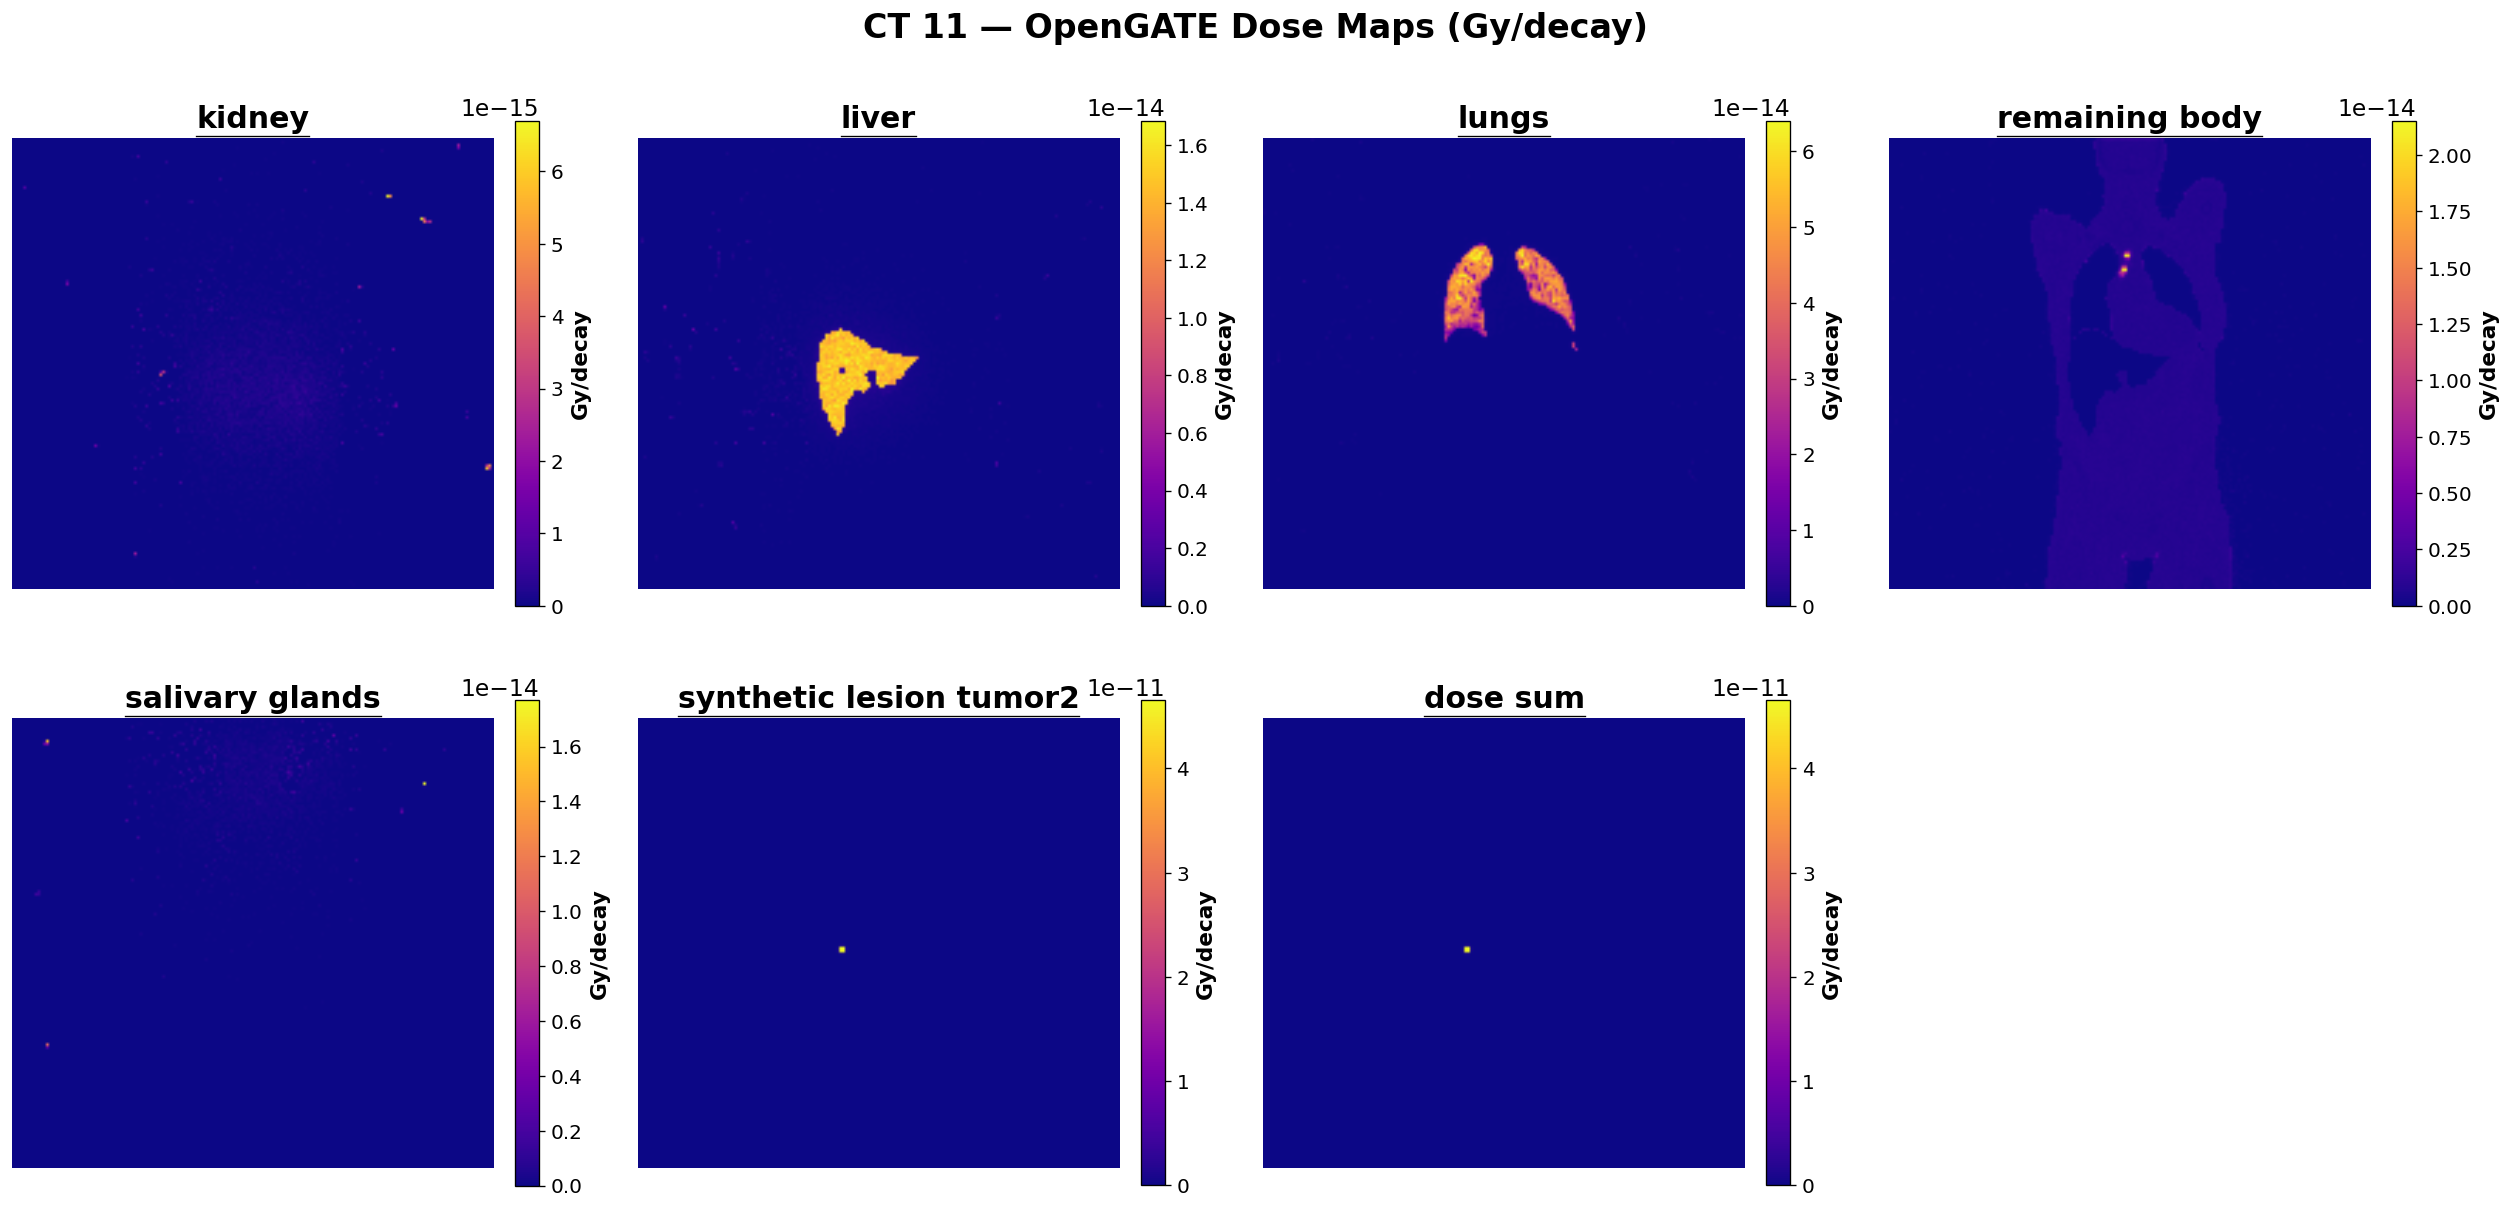

In [419]:
if not globals().get('SHOW_OPENGATE', False):
    print('6c OpenGATE skipped — set SHOW_OPENGATE = True in Setup')
else:
    _folders = _resolve_out_folders()
    _cfgs = globals().get('configs', {})
    for i, folder in enumerate(_folders):
        og_cfg = _cfgs.get(i,{}).get('phase_2',{}).get('opengate_stage',{})
        prefix = og_cfg.get('file_prefix','opengate_simulation')
        og_dir = os.path.join(folder, 'simulations', og_cfg.get('sub_dir_name','opengate_simulation'))
        og_work = os.path.join(og_dir, 'work_dir')

        tag = prefix + '_dose_'
        dose_roi_files = [f for f in list_files(og_dir,'.nii.gz') if os.path.basename(f).startswith(tag)]
        if not dose_roi_files:
            dose_roi_files = [f for f in list_files(og_work,'.nii.gz') if os.path.basename(f).startswith(tag)]

        dose_sum_path = None
        for candidate in [
            os.path.join(folder,'simulations', prefix+'_dose_sum.nii.gz'),
            os.path.join(og_dir, prefix+'_dose_sum.nii.gz'),
        ]:
            if os.path.exists(candidate):
                dose_sum_path = candidate; break

        all_dose = [(stem(p)[len(tag):] if stem(p).startswith(tag) else stem(p), p)
                    for p in dose_roi_files if not stem(p).endswith('_dose_sum')]
        if dose_sum_path:
            all_dose.append(('dose sum', dose_sum_path))

        if not all_dose:
            print(f'{ct_label(i)}: no OpenGATE dose maps found'); continue

        fig, axes, nrows, ncols = make_grid(len(all_dose), max_cols=4, pw=5.3, ph=5.3)
        fig.suptitle(f'{ct_label(i)} — OpenGATE Dose Maps (Gy/decay)')
        cmap = plot_spec('opengate','cmap','plasma')

        for j, (label, path) in enumerate(all_dose):
            ax = axes[j//ncols][j%ncols]
            img = sitk.ReadImage(path)
            arr = sitk.GetArrayFromImage(img)[::-1]
            sp  = img.GetSpacing()
            z, y, x = arr.shape
            _mode = globals().get('OPENGATE_SLICE_MODE') or globals().get('SLICE_MODE', 'mid')
            sl = get_slice(arr, axis=1, mode=_mode)
            im = ax.imshow(sl, cmap=cmap, aspect=med_aspect(sp[2],sp[0]), interpolation='bilinear')
            ax.set_title(label.replace('_',' ')); ax.axis('off')
            add_colorbar(fig, ax, im, 'Gy/decay')

        for j in range(len(all_dose), nrows*ncols):
            axes[j//ncols][j%ncols].set_visible(False)
        finish_plot(fig, f'ct_{i+1}_opengate_dose_maps')


### 6d — Voxel S-value Map (OpenGATE · Gy/decay)

CT 11  dose_sum  shape=(159,170,170)  vmax=4.172e-14 Gy/decay


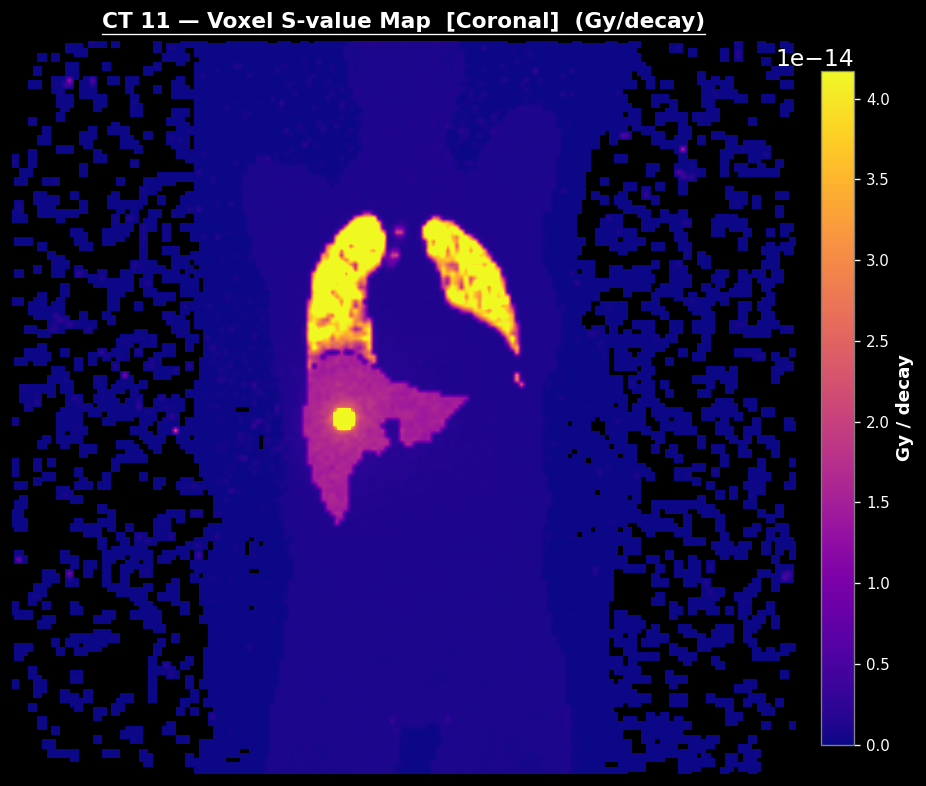

In [420]:
if not globals().get('SHOW_OPENGATE', False):
    print('6d OpenGATE dose sum skipped — set SHOW_OPENGATE = True in Setup')
else:
    _folders  = _resolve_out_folders()
    _cfgs     = globals().get('configs', {})
    cmap_ds   = plt.get_cmap(plot_spec('opengate', 'cmap', 'plasma')).copy()
    cmap_ds.set_under('black')
    _view     = globals().get('DOSE_SUM_VIEW_AXIS', 'coronal')
    _axis_map = {'axial': 0, 'coronal': 1, 'sagittal': 2}
    _axis     = _axis_map.get(_view, 1)
    _asp_axes = {0: (1, 0), 1: (2, 0), 2: (2, 1)}  # (sp idx numerator, denominator)

    for i, folder in enumerate(_folders):
        og_cfg = _cfgs.get(i, {}).get('phase_2', {}).get('opengate_stage', {})
        prefix = og_cfg.get('file_prefix', 'opengate_simulation')

        dose_sum_path = None
        for candidate in [
            os.path.join(folder, 'simulations', prefix + '_dose_sum.nii.gz'),
            os.path.join(folder, 'simulations',
                         og_cfg.get('sub_dir_name', 'opengate_simulation'),
                         prefix + '_dose_sum.nii.gz'),
        ]:
            if os.path.exists(candidate):
                dose_sum_path = candidate; break

        if dose_sum_path is None:
            print(f'{ct_label(i)}: opengate dose sum not found'); continue

        img = sitk.ReadImage(dose_sum_path)
        arr = sitk.GetArrayFromImage(img)[::-1]
        sp  = img.GetSpacing()          # (sp_x, sp_y, sp_z)
        z, y, x = arr.shape
        pos = arr[arr > 0]
        vm  = float(np.percentile(pos, 99.5)) if pos.size else float(arr.max() + 1e-9)
        print(f'{ct_label(i)}  dose_sum  shape=({z},{y},{x})  vmax={vm:.4g} Gy/decay')

        _mode = globals().get('DOSE_SLICE_MODE') or globals().get('SLICE_MODE', 'mid')
        sl    = get_slice(arr, axis=_axis, mode=_mode)
        ni, nj = _asp_axes[_axis]
        asp   = med_aspect(sp[ni], sp[nj])

        fig, ax = plt.subplots(figsize=(8, 8))
        fig.patch.set_facecolor('black')
        ax.set_facecolor('black')
        im = ax.imshow(sl, cmap=cmap_ds, vmin=1e-30, vmax=vm,
                       aspect=asp, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'{ct_label(i)} — Voxel S-value Map  [{_view.capitalize()}]  (Gy/decay)',
                     color='white', fontsize=13, pad=8)
        cb = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.03, shrink=0.85)
        cb.set_label('Gy / decay', color='white', fontsize=11)
        cb.ax.tick_params(colors='white', labelsize=9)
        cb.outline.set_edgecolor('grey')
        finish_plot(fig, f'ct_{i+1}_voxel_svalue_{_view}')


## 7 — Phase 3: Post-processing Outputs

### 7b — Per-ROI Activity Maps
*Shown before 7a since these use only PBPK + segmentation (no SPECT reconstruction needed).*

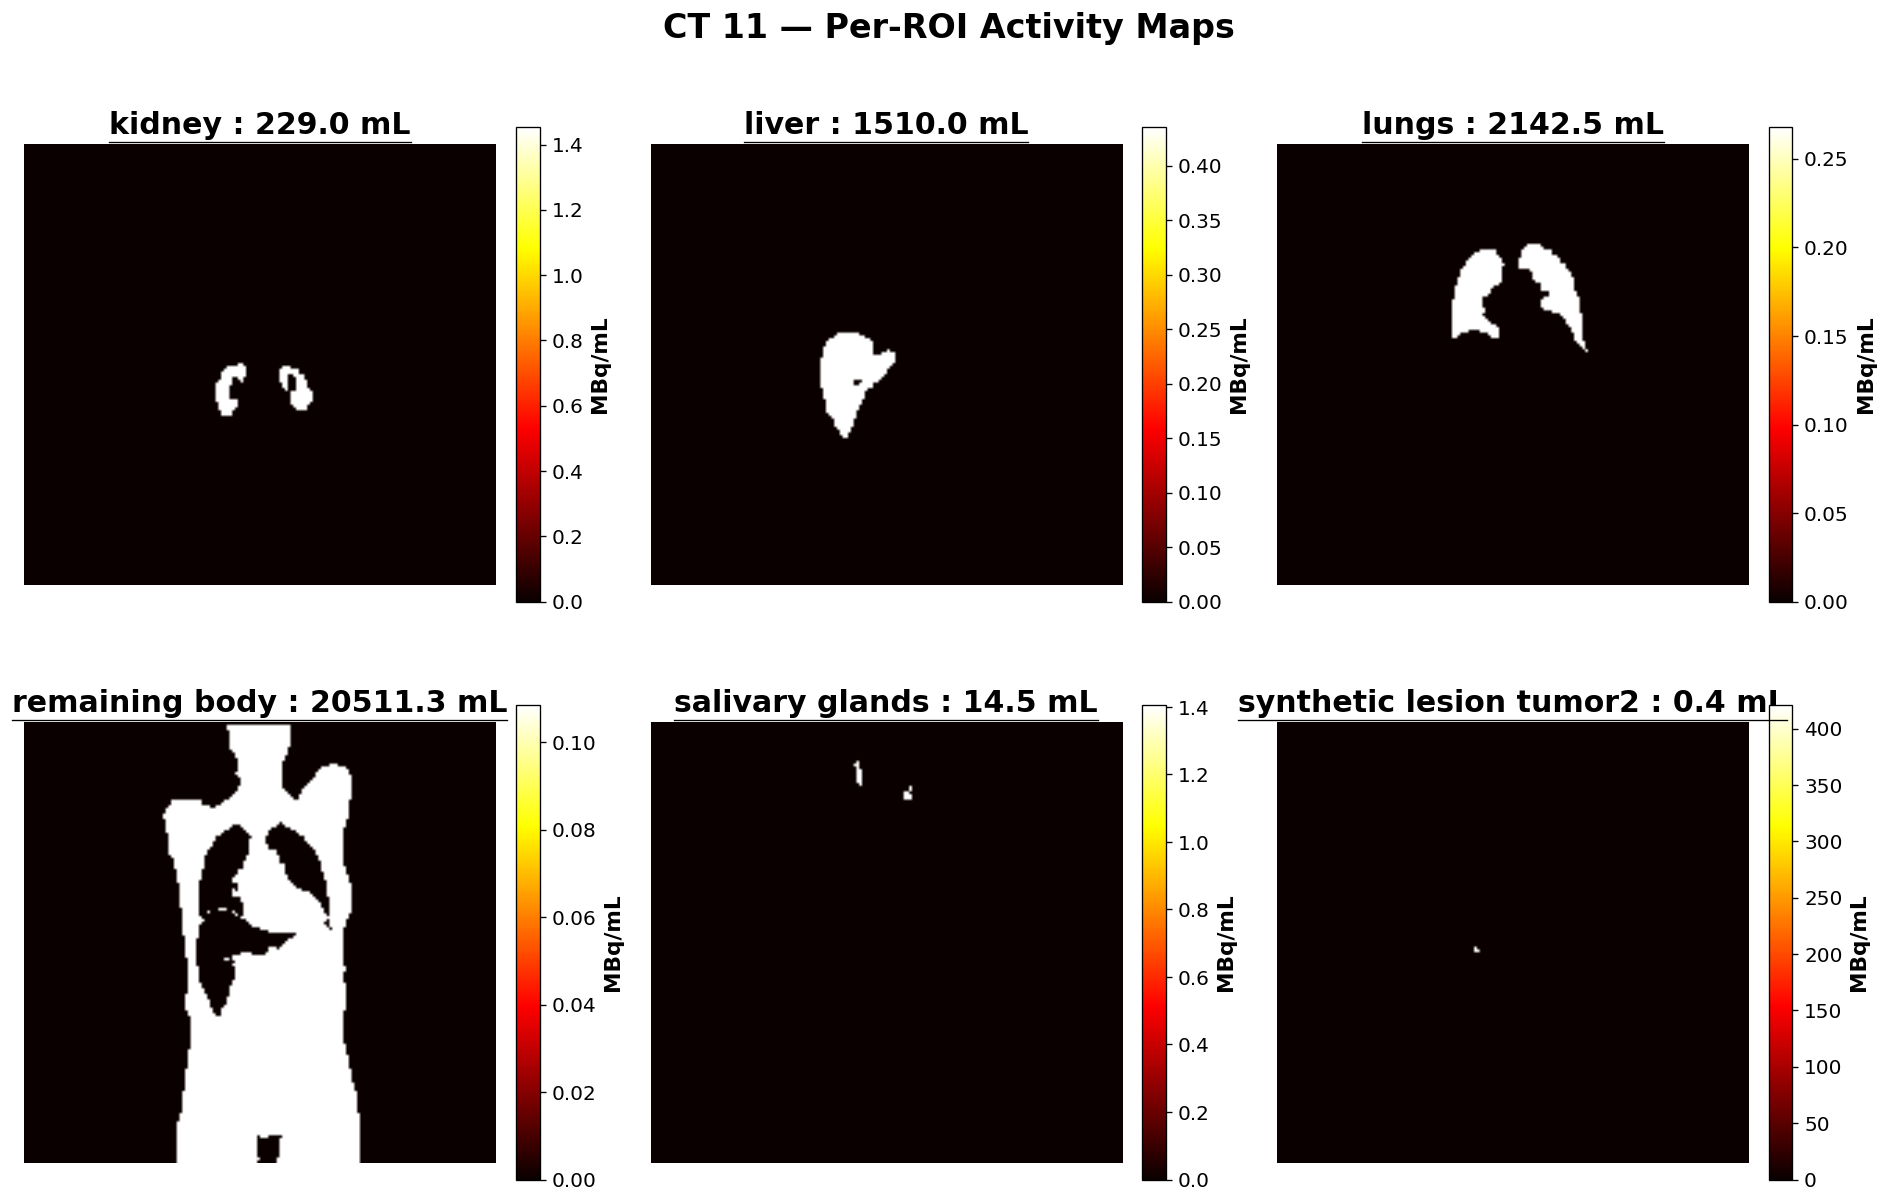

In [421]:
if not globals().get('SHOW_ROI_ACTIVITY', False):
    print('7b ROI activity maps skipped — set SHOW_ROI_ACTIVITY = True in Setup')
else:
    _folders = _resolve_out_folders()
    _cfgs = globals().get('configs', {})
    for i, folder in enumerate(_folders):
        work_dir = os.path.join(folder, 'post_processing', 'spect_postprocess', 'work_dir')
        act_files = list_files(work_dir, '_act_av.nii.gz')
        if not act_files:
            print(f'{ct_label(i)}: no per-ROI activity maps in {work_dir}'); continue

        sp_prefix = _cfgs.get(i,{}).get('phase_3',{}).get('spect_postprocess_stage',{}).get('file_prefix','spect_postprocess')
        labels = []
        for p in act_files:
            s = stem(p).replace('_act_av','')
            labels.append(s[len(sp_prefix)+1:] if s.startswith(sp_prefix+'_') else s)

        fig, axes, nrows, ncols = make_grid(len(act_files), max_cols=4, pw=5.3, ph=5.3)
        fig.suptitle(f'{ct_label(i)} — Per-ROI Activity Maps')
        cmap = plot_spec('activity','cmap','hot')

        for j, (path, label) in enumerate(zip(act_files, labels)):
            ax = axes[j//ncols][j%ncols]
            img = sitk.ReadImage(path)
            arr = sitk.GetArrayFromImage(img)[::-1]
            sp  = img.GetSpacing()
            z, y, x = arr.shape

            _mode = globals().get('ROI_ACT_SLICE_MODE') or globals().get('SLICE_MODE', 'mid')
            if _mode == 'max':
                sl = get_slice(arr, axis=1, mode='max')
            else:
                nz_yx = np.where(np.max(arr, axis=2) > 0)
                y_mid = int(np.round(np.median(nz_yx[1]))) if nz_yx[0].size > 0 else y // 2
                sl = arr[:, y_mid, :]
            pos = sl[sl > 0]
            vmax_roi = float(np.percentile(pos, 99)) if pos.size else float(sl.max()+1e-9)
            im = ax.imshow(sl, cmap=cmap, vmin=0, vmax=vmax_roi,
                           aspect=med_aspect(sp[2], sp[0]), interpolation='bilinear')
            ax.set_title(fmt_roi_label_with_vol(label, i, label.replace('_', ' '))); ax.axis('off')
            add_colorbar(fig, ax, im, 'MBq/mL')

        for j in range(len(act_files), nrows*ncols):
            axes[j//ncols][j%ncols].set_visible(False)
        finish_plot(fig, f'ct_{i+1}_roi_activity_maps')


### 7a — Reconstructed SPECT

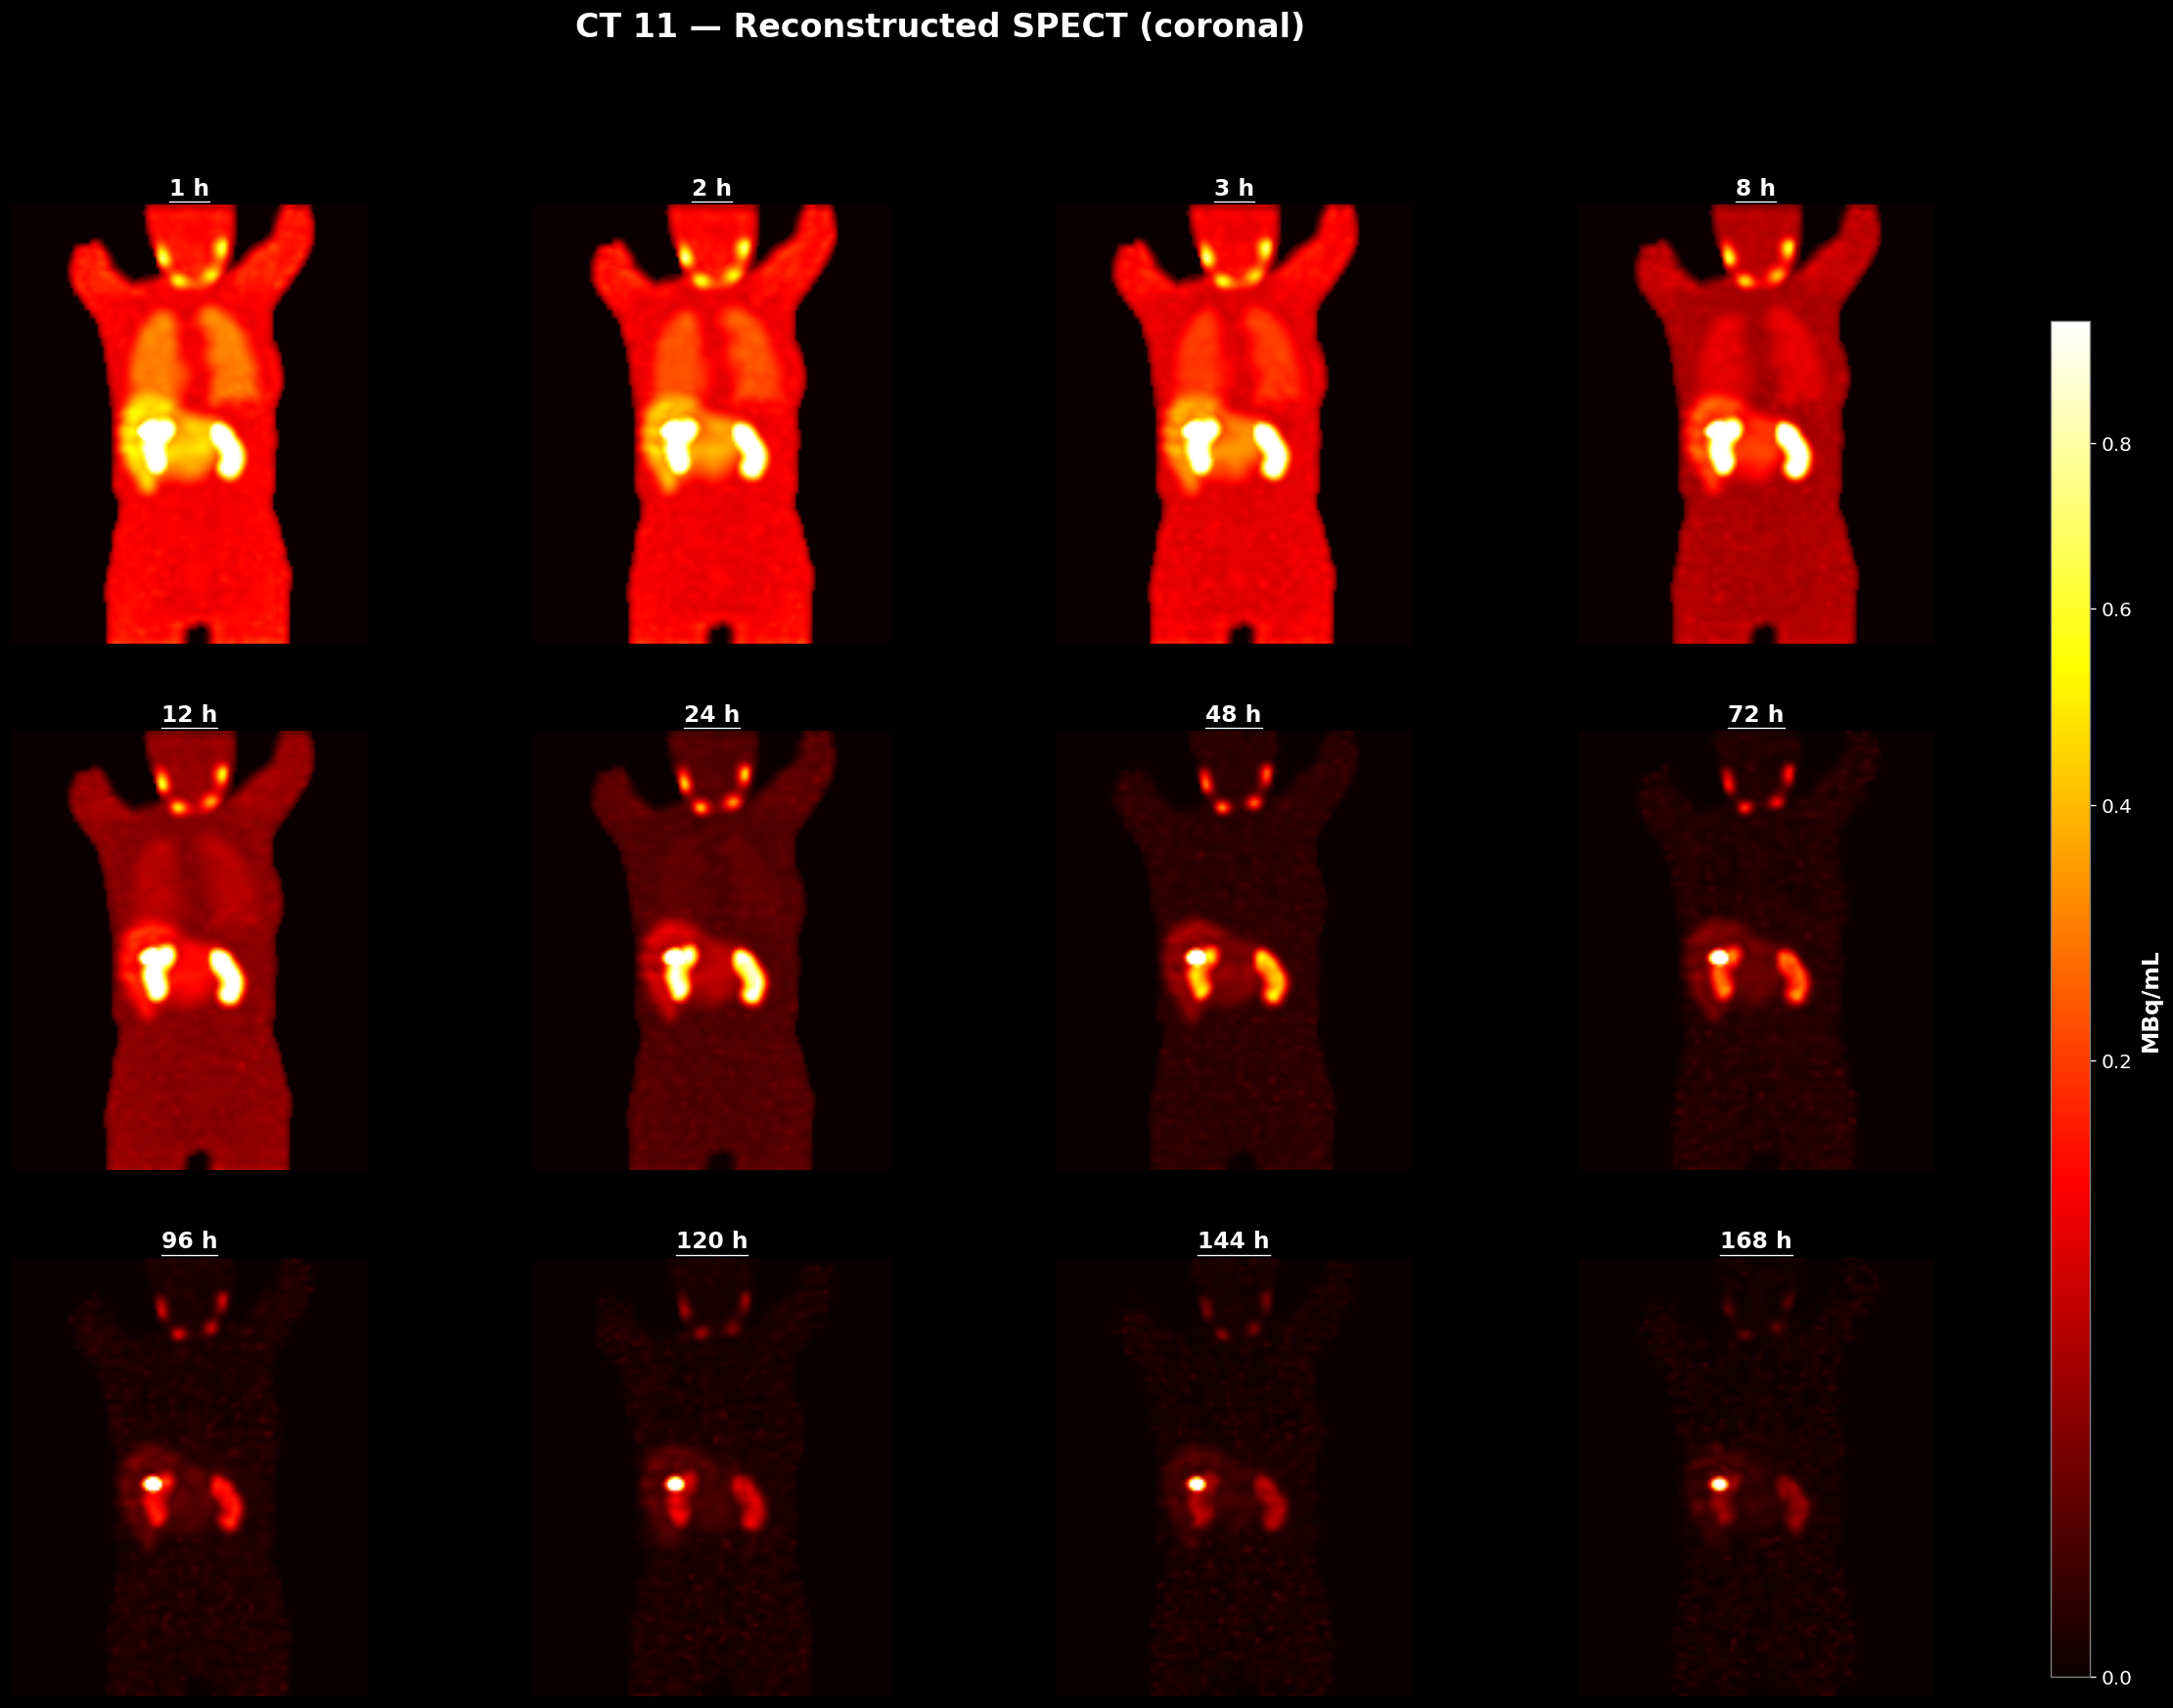

In [422]:
recon_paths_store = {}

if not globals().get('SHOW_SPECT', False):
    print('7a SPECT skipped — set SHOW_SPECT = True in Setup')
else:
    _folders = _resolve_out_folders()
    _view    = globals().get('SPECT_VIEW_AXIS', 'sagittal')   # 'axial','coronal','sagittal'

    for i, folder in enumerate(_folders):
        pp_dir = os.path.join(folder, 'post_processing')
        recons = sorted([os.path.join(pp_dir, f) for f in os.listdir(pp_dir)
                         if f.startswith('reconstructed_SPECT_') and f.endswith('.nii.gz')
                        ], key=lambda p: float(os.path.basename(p).replace('reconstructed_SPECT_','').replace('.nii.gz','')))                  if os.path.isdir(pp_dir) else []
        if not recons:
            print(f'{ct_label(i)}: no reconstructed SPECT'); continue

        frame_map = {os.path.basename(p).replace('reconstructed_SPECT_','').replace('.nii.gz',''):p for p in recons}
        recon_paths_store[i] = frame_map

        frame_labels = select_frame_labels(frame_map.keys(), globals().get('SPECT_FRAME_MODE','all'),
                                           globals().get('SPECT_SELECTED_FRAMES',[]))
        if not frame_labels:
            print(f'{ct_label(i)}: no frames selected'); continue

        # Load arrays + compute shared vmax
        arrs, vmax = {}, 0.0
        for lbl in frame_labels:
            img = sitk.ReadImage(frame_map[lbl])
            arr = sitk.GetArrayFromImage(img)[::-1]
            sp  = img.GetSpacing()
            arrs[lbl] = (arr, sp)
            pos = arr[arr > 0]
            if pos.size:
                vmax = max(vmax, float(np.percentile(pos, plot_spec('spect','percentile',99.5))))
        shared_vmax = vmax if globals().get('SPECT_SHARED_SCALE', True) and vmax > 0 else None

        n = len(frame_labels)
        nrows, ncols_per_row = optimal_grid(n, max_cols=7)

        # Use first image for reference dimensions
        ref_arr, ref_sp = arrs[frame_labels[0]]
        z, y, x = ref_arr.shape
        sp_x, sp_y, sp_z = ref_sp

        if _view == 'axial':
            asp = med_aspect(sp_y, sp_x); _ph = 4.5
        elif _view == 'coronal':
            asp = med_aspect(sp_z, sp_x); _ph = 5.5
        else:  # sagittal
            asp = med_aspect(sp_z, sp_y); _ph = 5.5

        fig, axes = plt.subplots(nrows, ncols_per_row,
                                  figsize=(_ph*ncols_per_row, _ph*nrows), squeeze=False)
        fig.patch.set_facecolor('black')
        fig.suptitle(f'{ct_label(i)} — Reconstructed SPECT ({_view})', color='white', fontsize=20)

        cmap = plot_spec('spect','cmap','hot')
        norm = mcolors.PowerNorm(gamma=0.5, vmin=0, vmax=shared_vmax) if shared_vmax else None
        last_im = None

        for idx, lbl in enumerate(frame_labels):
            arr, sp = arrs[lbl]
            z, y, x = arr.shape
            if _view == 'axial':     sl = arr[z//2, :, :]
            elif _view == 'coronal': sl = np.max(arr, axis=1)
            else:                    sl = arr[:, :, x//2]

            row, col = divmod(idx, ncols_per_row)
            ax = axes[row][col]
            ax.set_facecolor('black')
            kwargs = dict(cmap=cmap, aspect=asp, interpolation='bilinear')
            if norm: kwargs['norm'] = norm
            last_im = ax.imshow(sl, **kwargs)
            ax.axis('off')
            ax.set_title(f'{lbl} h', color='white', fontsize=14)

        for idx in range(n, nrows*ncols_per_row):
            r, c = divmod(idx, ncols_per_row)
            axes[r][c].set_visible(False)

        # Shared colorbar on far right
        if last_im is not None:
            cbar_ax = fig.add_axes([0.93, 0.12, 0.015, 0.70])
            cb = fig.colorbar(last_im, cax=cbar_ax)
            cb.set_label('MBq/mL', color='white', fontsize=14)
            cb.ax.tick_params(colors='white', labelsize=12)
            cb.outline.set_edgecolor('grey')

        finish_plot(fig, f'ct_{i+1}_reconstructed_spect', tight=False)

# Always build recon_paths_store for comparison setup
if not recon_paths_store:
    _folders = _resolve_out_folders()
    for i, folder in enumerate(_folders):
        pp_dir = os.path.join(folder, 'post_processing')
        if not os.path.isdir(pp_dir): continue
        frame_map = {os.path.basename(p).replace('reconstructed_SPECT_','').replace('.nii.gz',''):
                     os.path.join(pp_dir, p)
                     for p in os.listdir(pp_dir)
                     if p.startswith('reconstructed_SPECT_') and p.endswith('.nii.gz')}
        if frame_map:
            recon_paths_store[i] = frame_map
    if recon_paths_store:
        print(f'Recon paths loaded for {len(recon_paths_store)} patient(s) (not plotted)')



### 7c — Total Dose Map

CT 11  dose shape=(159,170,170)  max=1282 Gy


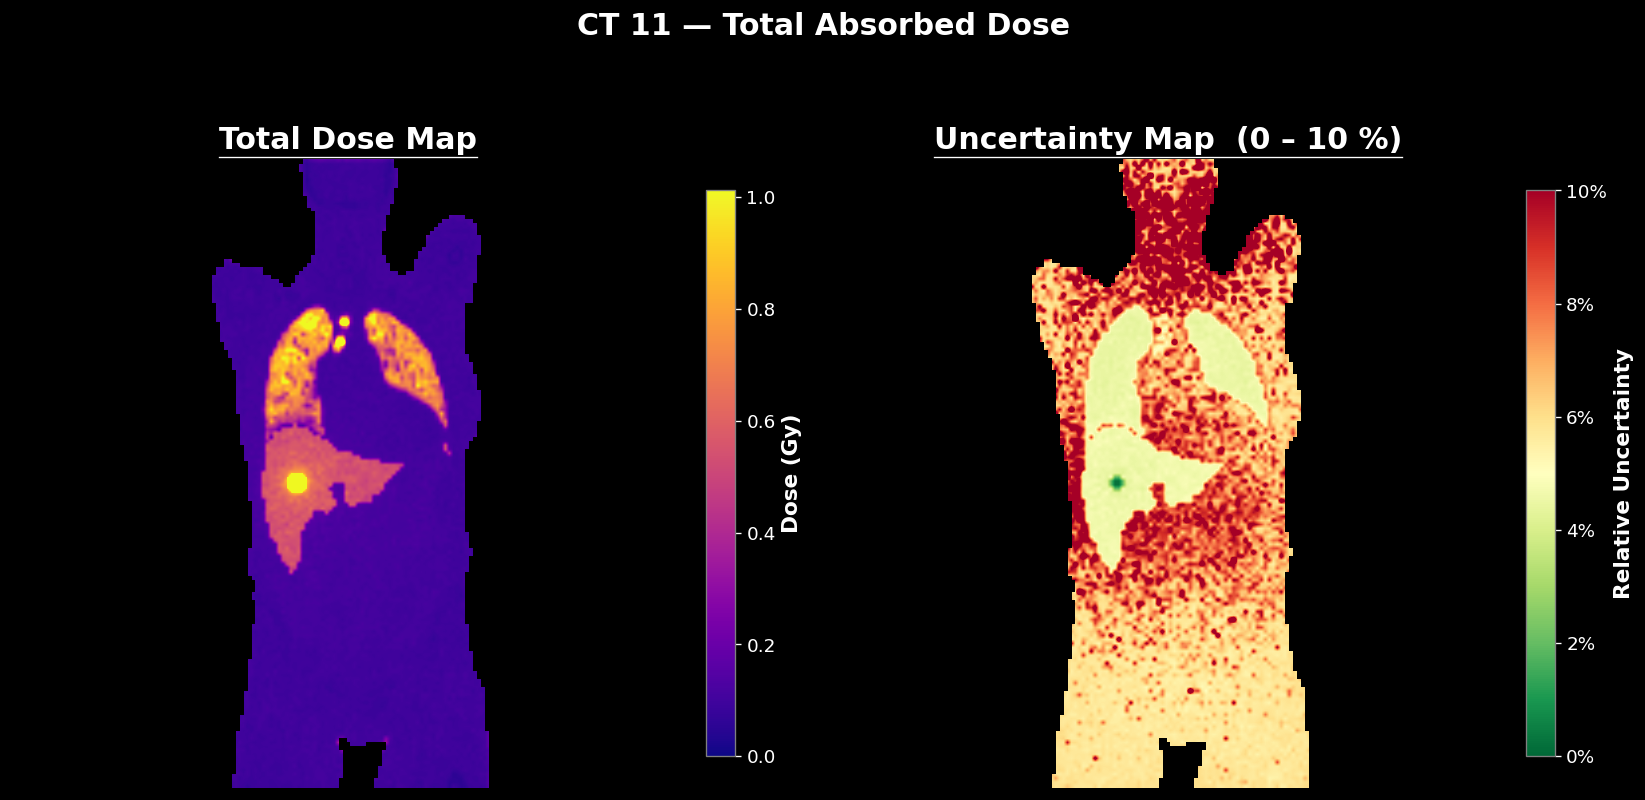

In [423]:
if not globals().get('SHOW_DOSE', False):
    print('7c Dose map skipped — set SHOW_DOSE = True in Setup')
else:
    _folders  = _resolve_out_folders()
    _unc_vmax = globals().get('DOSE_UNC_VMAX_PCT', 50) / 100.0  # e.g. 50 % → 0.5

    for i, folder in enumerate(_folders):
        dose_path = os.path.join(folder, 'post_processing', 'dosemap_postprocess_total_dose.nii.gz')
        unc_path  = os.path.join(folder, 'simulations', 'opengate_simulation_dose_sum_unc.nii.gz')
        if not os.path.exists(dose_path):
            print(f'{ct_label(i)}: total dose map not found'); continue

        img  = sitk.ReadImage(dose_path)
        arr  = sitk.GetArrayFromImage(img)[::-1]
        sp   = img.GetSpacing()
        z, y, x = arr.shape
        body_mask = arr > 0
        pos  = arr[body_mask]
        vm   = float(np.percentile(pos, plot_spec('dose','percentile',99.0))) if pos.size else float(arr.max()+1e-9)
        print(f'{ct_label(i)}  dose shape=({z},{y},{x})  max={arr.max():.4g} Gy')

        _mode   = globals().get('DOSE_SLICE_MODE') or globals().get('SLICE_MODE', 'mid')
        sl_dose = get_slice(arr, axis=1, mode=_mode)
        mask_sl = get_slice(body_mask.astype(np.uint8), axis=1, mode=_mode) > 0
        asp     = med_aspect(sp[2], sp[0])
        phys_h  = z * sp[2]; phys_w = x * sp[0]

        has_unc = os.path.exists(unc_path)
        ncols   = 2 if has_unc else 1
        fig_w   = 7
        fig_h   = max(3.0, fig_w * phys_h / phys_w)
        fig, axes = plt.subplots(1, ncols, figsize=(fig_w * ncols, fig_w), squeeze=False)
        axes = axes[0]
        fig.patch.set_facecolor('black')

        # ── Left: total dose map ─────────────────────────────────────────────
        cmap_dose = plt.get_cmap(plot_spec('dose','cmap','plasma')).copy()
        cmap_dose.set_bad('black')
        disp_dose = np.where(mask_sl, sl_dose, np.nan)
        im_dose = axes[0].imshow(disp_dose, cmap=cmap_dose, vmin=0, vmax=vm,
                                  aspect=asp, interpolation='bilinear')
        axes[0].axis('off')
        axes[0].set_facecolor('black')
        axes[0].set_title('Total Dose Map', color='white')
        cb_d = fig.colorbar(im_dose, ax=axes[0], fraction=0.04, pad=0.03, shrink=0.85)
        cb_d.set_label('Dose (Gy)', color='white', fontsize=13)
        cb_d.ax.tick_params(colors='white', labelsize=11)
        cb_d.outline.set_edgecolor('grey')

        # ── Right: uncertainty map ────────────────────────────────────────────
        if has_unc:
            unc_arr  = sitk.GetArrayFromImage(sitk.ReadImage(unc_path))[::-1]
            sl_unc   = unc_arr[:, y//2, :]
            disp_unc = np.where(mask_sl, sl_unc, np.nan)  # zero outside body → black

            cmap_unc = plt.get_cmap('RdYlGn_r').copy()
            cmap_unc.set_bad('black')
            axes[1].set_facecolor('black')
            im_unc = axes[1].imshow(disp_unc, cmap=cmap_unc, vmin=0, vmax=_unc_vmax,
                                     aspect=asp, interpolation='bilinear')
            axes[1].axis('off')
            axes[1].set_title(f'Uncertainty Map  (0 – {int(_unc_vmax*100)} %)', color='white')
            cb_u = fig.colorbar(im_unc, ax=axes[1], fraction=0.04, pad=0.03, shrink=0.85)
            cb_u.set_label('Relative Uncertainty', color='white', fontsize=13)
            cb_u.ax.yaxis.set_major_formatter(
                plt.matplotlib.ticker.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))
            cb_u.ax.tick_params(colors='white', labelsize=11)
            cb_u.outline.set_edgecolor('grey')

        fig.suptitle(f'{ct_label(i)} — Total Absorbed Dose', color='white', fontsize=18)
        fig.tight_layout(rect=[0, 0, 1, 0.93])
        finish_plot(fig, f'ct_{i+1}_total_dose', tight=False)


### 7d — Dose Integration Summary

In [424]:
dose_summary_store = {}

if not globals().get('SHOW_DOSE_SUMMARY', False):
    print('7d Dose summary skipped — set SHOW_DOSE_SUMMARY = True in Setup')
else:
    _folders = _resolve_out_folders()
    def pbpk_decays_for_roi(patient_idx, roi):
        if patient_idx not in pbpk_store or roi not in pbpk_store[patient_idx]: return np.nan
        t_min = np.asarray(pbpk_store[patient_idx]['time_hr'], float) * 60.0
        y_mbq = np.asarray(pbpk_store[patient_idx][roi], float)
        return float(np.trapezoid(y_mbq, t_min) * 60.0 * 1e6)

    for i, folder in enumerate(_folders):
        meta_path = os.path.join(folder, 'pipeline_metadata', 'dosemap_postprocess_stage.json')
        if not os.path.exists(meta_path):
            print(f'{ct_label(i)}: dose postprocess metadata not found'); continue
        m = load_json(meta_path)
        dose_summary_store[i] = m
        decays = m.get('cumulated_activities_per_roi_decays', {})
        range_hr = m.get('integration_range_hr', [])
        print(f'\n{ct_label(i)}: integration range = {range_hr} hr')
        if not decays:
            print('  No cumulated activity entries'); continue
        print(f"  {'ROI':20s} {'dose-stage CA (MBq·h)':>22s} {'PBPK CA (MBq·h)':>17s}")
        for roi, val in sorted(decays.items()):
            direct = pbpk_decays_for_roi(i, roi)
            print(f'  {roi:20s} {val/3.6e9:22.1f} {direct/3.6e9:17.1f}')



CT 11: integration range = [0.0, 1595.28] hr
  ROI                   dose-stage CA (MBq·h)   PBPK CA (MBq·h)
  kidney                              11185.9           11185.9
  liver                                9893.3            9893.3
  lungs                                4765.8            4765.8
  remaining_body                      31536.1           15034.7
  salivary_glands                       683.4             683.4
  synthetic_lesion_tumor2                 7652.7            7652.7


## 8 — SPECT Comparison Setup

### 8a — Build ROI Masks in SPECT Space

In [425]:
def physical_center(img):
    size = np.array(img.GetSize(), dtype=float)
    sp   = np.array(img.GetSpacing(), dtype=float)
    orig = np.array(img.GetOrigin(), dtype=float)
    direction = np.array(img.GetDirection(), dtype=float).reshape(3,3)
    return orig + direction @ ((size-1.0)/2.0*sp)

def set_center(img, target):
    out = sitk.Image(img)
    size = np.array(out.GetSize(), dtype=float)
    sp   = np.array(out.GetSpacing(), dtype=float)
    direction = np.array(out.GetDirection(), dtype=float).reshape(3,3)
    out.SetOrigin((target - direction @ ((size-1.0)/2.0*sp)).tolist())
    return out

def resample_nn(moving, reference):
    rs = sitk.ResampleImageFilter()
    rs.SetReferenceImage(reference)
    rs.SetInterpolator(sitk.sitkNearestNeighbor)
    rs.SetDefaultPixelValue(0)
    return rs.Execute(moving)

masks_recon       = {}
recon_imgs_sitk   = {}
recon_vox_ml      = {}
recon_arr_ref     = {}
mask_volume_store = {}

_folders = _resolve_out_folders()
roi_map_path = str(Path(OUTPUT_ROOT) / 'src' / 'data' / 'pipeline_roi_naming_map.json')
label_to_roi = {}
if os.path.exists(roi_map_path):
    roi_map = load_json(roi_map_path)
    label_to_roi = {int(k): v.lower() for k,v in roi_map.get('PyTheraTwin_Pipeline',{}).items()}

_rps = recon_paths_store if recon_paths_store else {}

for i, folder in enumerate(_folders):
    if i not in _rps:
        print(f'{ct_label(i)}: no recon paths — run 7a first or set SHOW_SPECT=True and re-run'); continue

    seg_path = os.path.join(folder, 'digital_twin', 'digital_twin.nii.gz')
    if not os.path.exists(seg_path):
        print(f'{ct_label(i)}: digital_twin.nii.gz not found'); continue

    frame_map = _rps[i]
    ref_label = sorted(frame_map.keys(), key=lambda k: float(k))[-1]
    ref_img   = sitk.ReadImage(frame_map[ref_label])
    sp_recon  = np.array(ref_img.GetSpacing(), dtype=float)
    recon_unit = normalize_unit(globals().get('SPECT_RECON_SPACING_UNIT','mm'))
    seg_unit   = normalize_unit(globals().get('SEGMENTATION_SPACING_UNIT','mm'))

    recon_imgs_sitk[i] = {lbl: sitk.ReadImage(p) for lbl, p in frame_map.items()}
    recon_vox_ml[i]    = voxel_volume_ml(sp_recon, recon_unit)
    recon_arr_ref[i]   = (sitk.GetArrayFromImage(ref_img)[::-1], sp_recon)

    seg_img = sitk.ReadImage(seg_path)
    seg_img_ru = scale_img_units(seg_img, seg_unit, recon_unit)
    seg_centered = set_center(seg_img_ru, physical_center(ref_img))
    seg_in_recon = resample_nn(seg_centered, ref_img)
    seg_arr = sitk.GetArrayFromImage(seg_in_recon).astype(np.int16)

    masks_recon[i]       = {}
    mask_volume_store[i] = {}
    for lbl in np.unique(seg_arr):
        if lbl == 0: continue
        roi_name = label_to_roi.get(int(lbl), f'label_{lbl}')
        mask = (seg_arr == lbl)
        masks_recon[i][roi_name] = mask
        mask_volume_store[i][roi_name] = {'voxels': int(mask.sum()), 'volume_ml': float(mask.sum()*recon_vox_ml[i])}

    print(f'{ct_label(i)}: {len(masks_recon[i])} ROI masks built  recon_vox={recon_vox_ml[i]:.4f} mL')
    for roi, v in mask_volume_store[i].items():
        print(f'  {roi:25s} {v["voxels"]:6d} vox  {v["volume_ml"]:.2f} mL')


CT 11: 41 ROI masks built  recon_vox=0.1106 mL
  remaining_body            185468 vox  20511.28 mL
  kidney                      2071 vox  229.04 mL
  liver                      13654 vox  1510.02 mL
  spleen                      3214 vox  355.44 mL
  heart                       4770 vox  527.52 mL
  salivary_glands              131 vox  14.49 mL
  lungs                      19373 vox  2142.50 mL
  adrenal_glands                46 vox  5.09 mL
  thyroid_gland                 99 vox  10.95 mL
  gallbladder                  212 vox  23.45 mL
  pancreas                     365 vox  40.37 mL
  esophagus                    405 vox  44.79 mL
  trachea                      278 vox  30.74 mL
  urinary_bladder             1110 vox  122.76 mL
  brain                       4702 vox  520.00 mL
  kidney_cyst                    1 vox  0.11 mL
  spinal_cord                  862 vox  95.33 mL
  aorta                       1964 vox  217.20 mL
  pulmonary_vein               218 vox  24.11 mL
  brachioce

### 8b — Mask Overlay Sanity Check

In [ ]:
if not globals().get('SHOW_MASK_OVERLAY', False):
    print('8b mask overlay skipped — set SHOW_MASK_OVERLAY = True in Setup')
elif not masks_recon:
    print('8b: run 8a first')
else:
    for i in masks_recon:
        arr_ref, sp_recon = recon_arr_ref[i]
        sp_x, sp_y, sp_z  = sp_recon
        rois = [r for r in masks_recon[i] if r != 'background']
        if not rois:
            print(f'{ct_label(i)}: no masks'); continue

        fig, axes, nrows, ncols = make_grid(len(rois), max_cols=5, pw=4.5, ph=4.5)
        fig.suptitle(f'{ct_label(i)} — ROI Masks in SPECT Space (latest frame)')
        image_cmap   = plot_spec('mask','image_cmap','hot')
        contour_color = plot_spec('mask','contour_color','cyan')

        for j, roi in enumerate(rois):
            ax = axes[j//ncols][j%ncols]
            mask = masks_recon[i][roi][::-1]   # display orientation
            pts  = np.argwhere(mask)
            if pts.size == 0:
                ax.set_visible(False); continue

            # Find coronal slice through the non-zero centre of the ROI
            y_mid = int(np.round(np.median(pts[:, 1])))
            sl_recon = arr_ref[:, y_mid, :]    # shape (z, x)
            sl_mask  = mask[:, y_mid, :]

            pos = sl_recon[np.isfinite(sl_recon) & (sl_recon > 0)]
            vmax_r = float(np.percentile(pos, 99)) if pos.size else 1.0

            asp = med_aspect(sp_z, sp_x)       # physical aspect ratio
            ax.imshow(sl_recon, cmap=image_cmap, vmin=0, vmax=vmax_r,
                      aspect=asp, interpolation='bilinear')
            ax.contour(sl_mask.astype(np.uint8), levels=[0.5],
                       colors=contour_color, linewidths=1.5)
            ax.set_title(fmt_roi_label_with_vol(roi, i, roi.replace('_', ' ')), fontsize=13)
            ax.axis('off')

        for j in range(len(rois), nrows*ncols):
            axes[j//ncols][j%ncols].set_visible(False)
        finish_plot(fig, f'ct_{i+1}_mask_overlay')


### 8c — Extract SPECT TACs

In [ ]:
def roi_stats(arr_zyx, mask_zyx, vox_vol_ml):
    n = int(mask_zyx.sum())
    if n == 0: return 0.0, 0.0, 0
    mean_mbq_ml = float(np.mean(arr_zyx[mask_zyx]))
    total_mbq   = float(np.sum(arr_zyx[mask_zyx]) * vox_vol_ml)
    return mean_mbq_ml, total_mbq, n

spect_tacs = {}

for i in masks_recon:
    frame_map   = recon_imgs_sitk[i]
    frame_labels = sorted(frame_map.keys(), key=lambda k: float(k))
    rois   = [r for r in masks_recon[i] if r != 'background']
    vox_ml = recon_vox_ml[i]
    spect_tacs[i] = {roi: {'frame_hr':[],'sum_mbq':[],'mean_mbq_ml':[],'n_voxels':[]} for roi in rois}

    for lbl in frame_labels:
        arr = sitk.GetArrayFromImage(frame_map[lbl]).astype(np.float32)
        for roi in rois:
            mask = masks_recon[i][roi]
            if arr.shape != mask.shape:
                print(f'{ct_label(i)} {roi}: shape mismatch'); continue
            mean_c, total, n_vox = roi_stats(arr, mask, vox_ml)
            spect_tacs[i][roi]['frame_hr'].append(float(lbl))
            spect_tacs[i][roi]['sum_mbq'].append(total)
            spect_tacs[i][roi]['mean_mbq_ml'].append(mean_c)
            spect_tacs[i][roi]['n_voxels'].append(n_vox)

    print(f'{ct_label(i)}: SPECT TACs extracted  frames={frame_labels}  ROIs={rois}')


CT 11: SPECT TACs extracted  frames=['1', '2', '3', '8', '12', '24', '48', '72', '96', '120', '144', '168']  ROIs=['remaining_body', 'kidney', 'liver', 'spleen', 'heart', 'salivary_glands', 'lungs', 'adrenal_glands', 'thyroid_gland', 'gallbladder', 'pancreas', 'esophagus', 'trachea', 'urinary_bladder', 'brain', 'kidney_cyst', 'spinal_cord', 'aorta', 'pulmonary_vein', 'brachiocephalic_vessels', 'carotid_arteries', 'portal_vein', 'iliac_arteries', 'iliac_veins', 'atrial_appendage', 'superior_vena_cava', 'inferior_vena_cava', 'eyes', 'eye_lenses', 'optic_nerves', 'nasopharynx', 'oropharynx', 'hypopharynx', 'nasal_cavity', 'auditory_canal', 'soft_palate', 'hard_palate', 'gi_tract', 'bone', 'muscle', 'synthetic_lesion_tumor2']


## 9 — Comparison 1: PBPK vs Reconstructed SPECT TACs

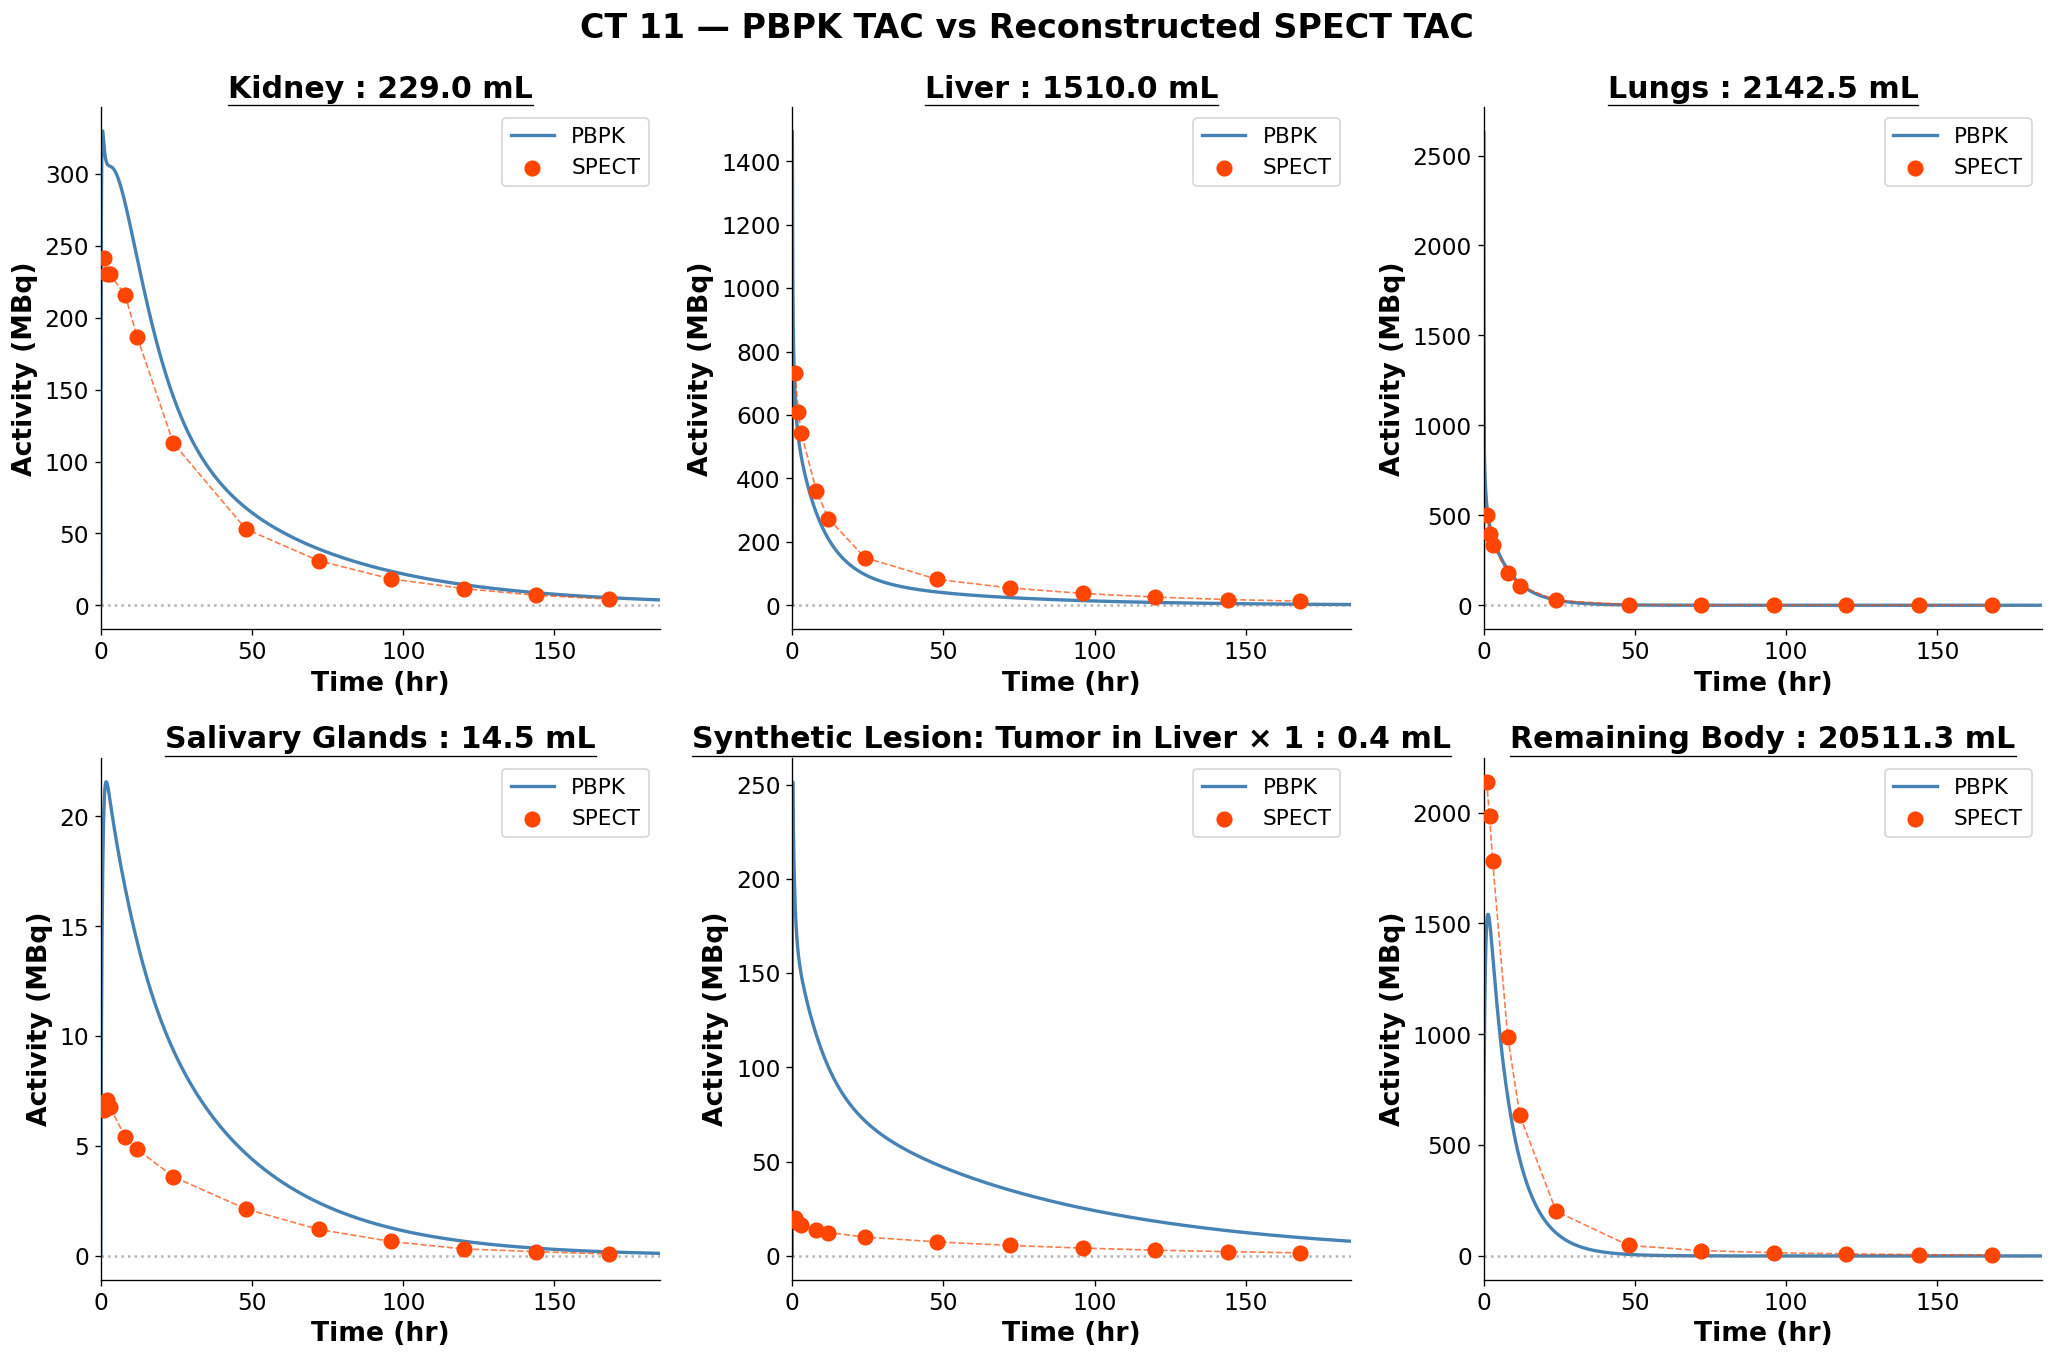

,ROI,Frame (hr),SPECT (MBq),PBPK (MBq),Diff (MBq),% Error
0,kidney,1.000000,241.249000,321.100000,-79.852000,-24.900000
1,kidney,2.000000,230.347000,307.419000,-77.072000,-25.100000
2,kidney,3.000000,230.161000,305.488000,-75.327000,-24.700000
3,kidney,8.000000,216.109000,280.023000,-63.913000,-22.800000
4,kidney,12.000000,186.854000,241.611000,-54.757000,-22.700000
5,kidney,24.000000,112.737000,144.929000,-32.192000,-22.200000
6,kidney,48.000000,52.951000,67.653000,-14.702000,-21.700000
7,kidney,72.000000,30.966000,39.195000,-8.229000,-21.000000
8,kidney,96.000000,18.350000,23.648000,-5.298000,-22.400000
9,kidney,120.000000,11.603000,14.347000,-2.744000,-19.100000


In [ ]:
# ── Per-run comparison filters (edit here) ───────────────────────────────────
_EXCLUDE_ROIS   = globals().get('COMPARISON_EXCLUDE_ROIS', [])    # e.g. ['liver']
_EXCLUDE_FRAMES = globals().get('COMPARISON_EXCLUDE_FRAMES', [])  # e.g. [168]
_ERR_LIMIT      = globals().get('COMPARISON_ERROR_LIMIT_PCT', None)  # e.g. 150

def simulated_rois_for_patient(i):
    rois = set()
    meta = simind_meta_store.get(i, {})
    rois.update(str(r).lower() for r in meta.get('roi_list',[]) if r)
    if not rois:
        cfg_rois = configs.get(i,{}).get('phase_2',{}).get('simind_stage',{}).get('roi_subset',[])
        rois.update(str(r).lower() for r in cfg_rois if r)
    if not globals().get('INCLUDE_REMAINING_BODY_IN_COMPARISON', False):
        rois.discard('remaining_body')
    return rois

def comparison_rois_for_patient(i, available):
    simulated = simulated_rois_for_patient(i) if globals().get('COMPARE_ONLY_SIMULATED_ROIS',True) else None
    skip = globals().get('SKIP_ROIS_COMPARISON', {'remaining_body','background'})
    ex   = {r.lower() for r in _EXCLUDE_ROIS}
    out  = []
    for roi in available:
        k = roi.lower()
        if k in skip or k in ex: continue
        if not globals().get('INCLUDE_REMAINING_BODY_IN_COMPARISON',False) and k=='remaining_body': continue
        if simulated is not None and simulated and k not in simulated: continue
        out.append(roi)
    return sorted(out)

def array_after_frame_filter(t, *ys):
    t = np.asarray(t, float); ys = [np.asarray(y,float) for y in ys]
    order = np.argsort(t); t = t[order]; ys = [y[order] for y in ys]
    ex_set = {float(f) for f in _EXCLUDE_FRAMES}
    keep = np.array([not any(abs(tv-f)<0.01 for f in ex_set) for tv in t])
    if globals().get('SKIP_LAST_FRAME',False) and keep.sum()>1:
        last = np.where(keep)[0][-1]; keep[last] = False
    t = t[keep]; ys = [y[keep] for y in ys]
    return (t, *ys)

if not globals().get('SHOW_COMPARISON', False):
    print('9a Comparison skipped — set SHOW_COMPARISON = True in Setup')
elif not spect_tacs:
    print('9a: run 8c first')
else:
    diff_store = {}
    pbpk_color = plot_spec('comparison','pbpk_color','steelblue')
    spect_color = plot_spec('comparison','spect_color','orangered')
    colors_pbpk = plot_spec('pbpk','colors',['#1f77b4','#d62728','#2ca02c','#9467bd','#8c564b','#e377c2','#17becf','#bcbd22'])

    for i in spect_tacs:
        if i not in pbpk_store: continue
        diff_store[i] = {}
        pbpk_t = pbpk_store[i]['time_hr']
        available = [r for r in spect_tacs[i] if spect_tacs[i][r]['sum_mbq']]
        plot_rois = comparison_rois_for_patient(i, available)
        if not plot_rois:
            print(f'{ct_label(i)}: no ROIs after filters'); continue

        for roi in plot_rois:
            pbpk_key = roi.lower()
            if pbpk_key not in pbpk_store[i]: continue
            t_hr = np.array(spect_tacs[i][roi]['frame_hr'])
            y_s  = np.array(spect_tacs[i][roi]['sum_mbq'])
            y_p  = np.interp(t_hr, pbpk_t, pbpk_store[i][pbpk_key])
            t_hr, y_s, y_p = array_after_frame_filter(t_hr, y_s, y_p)
            diff_store[i][roi] = {
                'frame_hr': t_hr, 'diff_mbq': y_s-y_p,
                'pct_err': pct(y_s, y_p), 'y_spect': y_s, 'y_pbpk': y_p,
            }

    for i, diffs in diff_store.items():
        plot_rois = sorted(diffs.keys(), key=lambda r: (r.lower() == 'remaining_body', r))
        if not plot_rois: continue
        pbpk_t = pbpk_store[i]['time_hr']
        all_frames = np.concatenate([diffs[r]['frame_hr'] for r in plot_rois if len(diffs[r]['frame_hr'])])
        xlim = comparison_xlim(all_frames)

        # ── TAC overlay per ROI ─────────────────────────────────────────────
        fig, axes, nrows, ncols = make_grid(len(plot_rois), max_cols=4, pw=5.8, ph=5.8)
        fig.suptitle(f'{ct_label(i)} — PBPK TAC vs Reconstructed SPECT TAC')

        for j, roi in enumerate(plot_rois):
            ax = axes[j//ncols][j%ncols]
            d  = diffs[roi]
            ax.plot(pbpk_t, pbpk_store[i][roi.lower()], lw=2, color=pbpk_color, label='PBPK')
            ax.scatter(d['frame_hr'], d['y_spect'], s=75, color=spect_color, zorder=5, label='SPECT')
            ax.plot(d['frame_hr'], d['y_spect'], '--', color=spect_color, lw=1, alpha=0.7)
            if xlim: ax.set_xlim(*xlim)
            ax.set_title(fmt_roi_label_with_vol(roi, i))
            ax.axhline(0, color='gray', lw=1.5, ls=':', alpha=0.6)
            ax.set_xlabel('Time (hr)'); ax.set_ylabel('Activity (MBq)')
            ax.legend(fontsize=13); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        for j in range(len(plot_rois), nrows*ncols):
            axes[j//ncols][j%ncols].set_visible(False)
        finish_plot(fig, f'ct_{i+1}_comparison1_tac')

        # ── Error table: SPECT, PBPK, diff, % error per ROI per frame ──────
        import pandas as pd
        from IPython.display import display
        _rows = []
        for roi in plot_rois:
            d = diffs[roi]
            for fr, ys, yp, dm, pe in zip(d['frame_hr'], d['y_spect'], d['y_pbpk'], d['diff_mbq'], d['pct_err']):
                _rows.append({'ROI': roi.replace('_', ' '), 'Frame (hr)': round(float(fr), 1),
                              'SPECT (MBq)': round(float(ys), 3), 'PBPK (MBq)': round(float(yp), 3),
                              'Diff (MBq)': round(float(dm), 3), '% Error': round(float(pe), 1)})
        _df = pd.DataFrame(_rows)
        display(_df.style.set_caption(f'{ct_label(i)} — Comparison 1: Values & Error'))


### 9b — Comparison 1: Average Across Patients

In [ ]:
comparison1_summary_store = {}

if not globals().get('SHOW_COMPARISON', False):
    print('9b skipped')
elif 'diff_store' not in globals() or len(diff_store) < 2:
    print('9b: need diff_store from 9a with >=2 patients')
else:
    all_rois   = sorted(set().union(*[set(d.keys()) for d in diff_store.values() if d]))
    all_frames = sorted({float(f) for d in diff_store.values() for r in d.values() for f in r['frame_hr']})
    patient_idxs = sorted(diff_store.keys())

    if all_rois and all_frames:
        frame_arr = np.asarray(all_frames, float)
        for roi in all_rois:
            diff_stack = np.full((len(patient_idxs), len(all_frames)), np.nan)
            err_stack  = np.full((len(patient_idxs), len(all_frames)), np.nan)
            for row_idx, pidx in enumerate(patient_idxs):
                if roi not in diff_store.get(pidx,{}): continue
                d = diff_store[pidx][roi]
                pf = np.asarray(d['frame_hr'], float)
                for col_idx, frame in enumerate(all_frames):
                    m = np.where(np.isclose(pf, frame, atol=0.01))[0]
                    if m.size:
                        diff_stack[row_idx, col_idx] = d['diff_mbq'][m[0]]
                        err_stack[row_idx, col_idx]  = d['pct_err'][m[0]]
            mean_d, std_d, n_d = nanmean_std_count(diff_stack, axis=0)
            mean_e, std_e, n_e = nanmean_std_count(err_stack, axis=0)
            med_d,  iqr_d      = nanmedian_iqr(diff_stack, axis=0)
            med_e,  iqr_e      = nanmedian_iqr(err_stack, axis=0)
            comparison1_summary_store[roi] = {
                'frame_hr': frame_arr, 'mean_diff_mbq': mean_d, 'std_diff_mbq': std_d,
                'mean_pct_err': mean_e, 'std_pct_err': std_e, 'n': n_d,
                'med_diff_mbq': med_d, 'iqr_diff_mbq': iqr_d,
                'med_pct_err': med_e, 'iqr_pct_err': iqr_e,
            }

        import pandas as pd
        from IPython.display import display
        _rows = []
        for roi in all_rois:
            s = comparison1_summary_store[roi]
            for fr, md_v, sd_v, me_v, se_v, med_d, iqr_d, med_e, iqr_e, n_v in zip(
                    s['frame_hr'], s['mean_diff_mbq'], s['std_diff_mbq'],
                    s['mean_pct_err'], s['std_pct_err'],
                    s['med_diff_mbq'], s['iqr_diff_mbq'],
                    s['med_pct_err'], s['iqr_pct_err'], s['n']):
                _rows.append({
                    'ROI': roi.replace('_', ' '), 'Frame (hr)': round(float(fr), 1),
                    'Mean Diff (MBq)': round(float(md_v), 3), 'Std Diff (MBq)': round(float(sd_v), 3),
                    'Med Diff (MBq)': round(float(med_d), 3), 'IQR Diff (MBq)': round(float(iqr_d), 3),
                    'Mean % Err': round(float(me_v), 1), 'Std % Err': round(float(se_v), 1),
                    'Med % Err': round(float(med_e), 1), 'IQR % Err': round(float(iqr_e), 1),
                    'N': int(n_v),
                })
        _df = pd.DataFrame(_rows)
        display(_df.style.set_caption(f'Comparison 1 — Average Across {len(patient_idxs)} Patients'))


9b: need diff_store from 9a with >=2 patients


## 10 — Comparison 2: Bi-exponential Kinetics


CT 11 — Fitting Parameters
  ROI                    Src        A (MBq)  k_slow (1/hr)  k_fast (1/hr)    σ (MBq)
  --------------------------------------------------------------------------------
  kidney                 PBPK       341.005        0.03245        5.12144     2.5711
  kidney                 SPECT      255.632        0.03021        3.54699     7.4513
  liver                  PBPK       597.556        0.07764       50.31764     6.3220
  liver                  SPECT      731.366        0.07877       35.42964    37.0486
  lungs                  PBPK       613.539        0.13873       43.63537     2.5221
  lungs                  SPECT      549.926        0.14427       76.11142    10.7883
  remaining_body         PBPK      1968.769        0.12492        2.10983     1.0793
  remaining_body         SPECT     2489.502        0.11301        3.38797    18.3800
  salivary_glands        PBPK        21.493        0.03217        3.18938     0.1070
  salivary_glands        SPECT        7

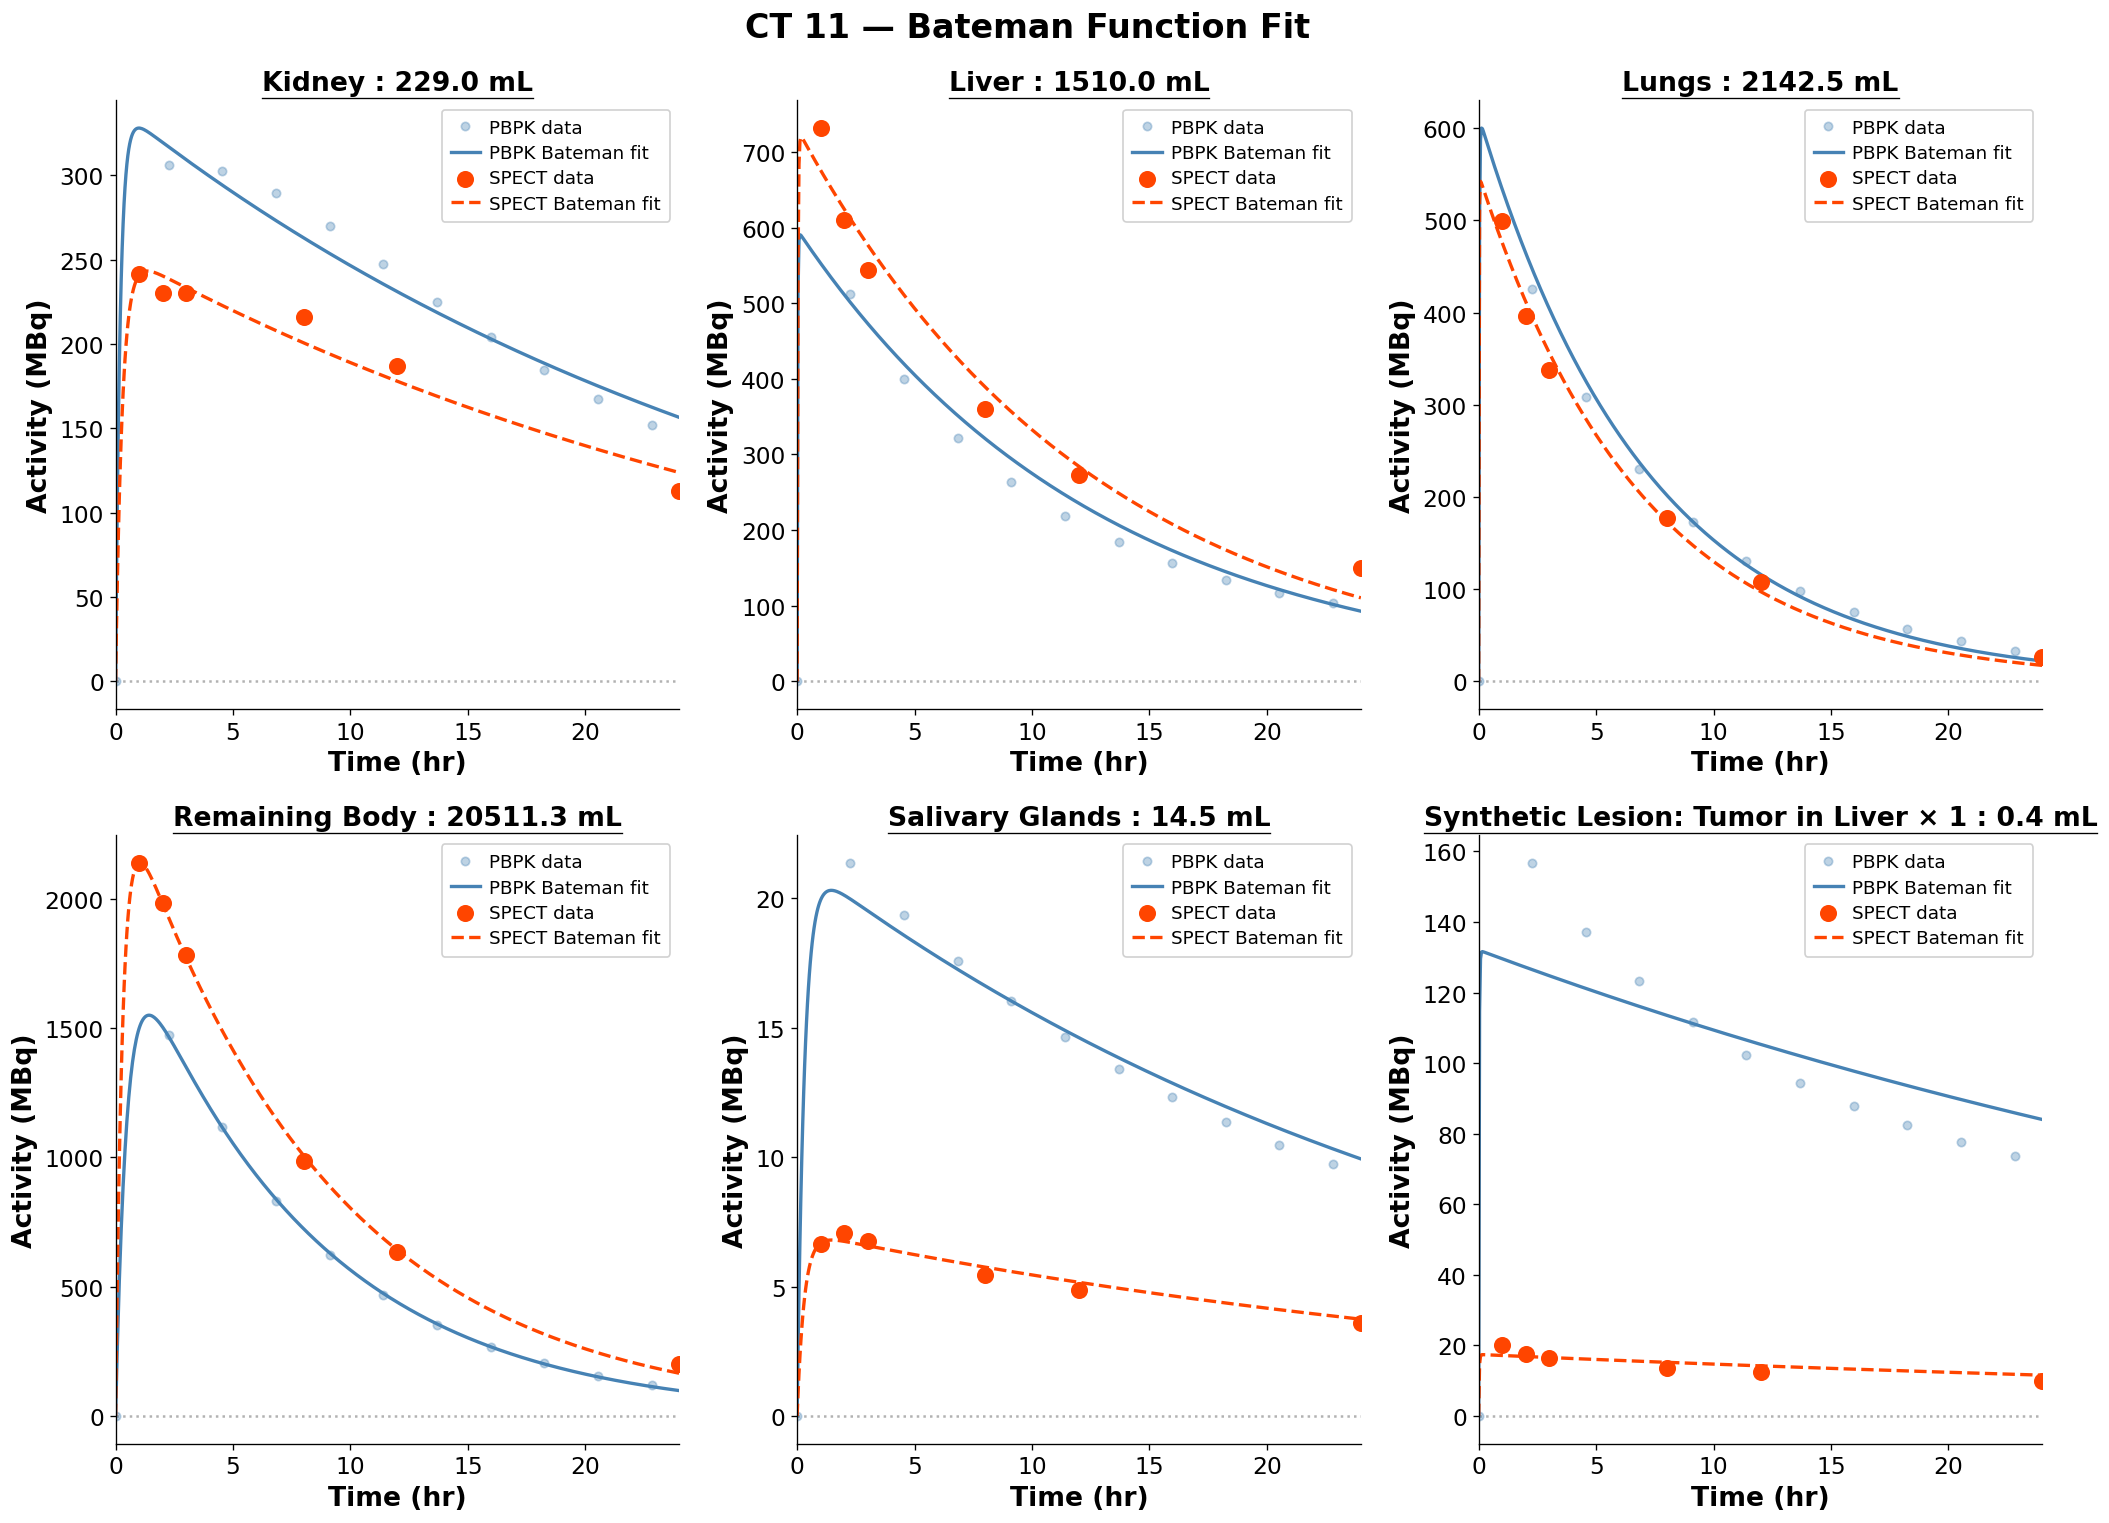

In [ ]:
def bateman(t, A, k_slow, k_fast):
    """Bateman-type function: A*(exp(-k_slow*t) - exp(-k_fast*t)), y(0)=0."""
    return A * (np.exp(-k_slow * t) - np.exp(-k_fast * t))

def _bateman_delta(t, A, k_slow, delta):
    """Internal fitting form: delta = k_fast - k_slow (>0), enforces k_fast > k_slow."""
    return A * (np.exp(-k_slow * t) - np.exp(-(k_slow + delta) * t))

def downsample_xy(t, y, max_pts):
    t, y = np.asarray(t, float), np.asarray(y, float)
    if t.size <= max_pts: return t, y
    idx = np.unique(np.linspace(0, t.size - 1, max_pts).astype(int))
    return t[idx], y[idx]

def fit_bateman(t, y):
    """Fit Bateman function. Returns ([A, k_slow, k_fast], sigma_rms).
    Fits internally with delta=k_fast-k_slow to enforce k_fast>k_slow (prevents
    the optimizer from producing unphysical sharp spikes at t=0).
    Returned popt is [A, k_slow, k_fast] for clean downstream use."""
    t, y = np.asarray(t, float), np.asarray(y, float)
    mask = np.isfinite(t) & np.isfinite(y) & (y >= 0)
    t, y = t[mask], y[mask]
    if t.size < 3:
        raise ValueError(f"Need ≥3 points, got {t.size}")
    p0 = [max(float(np.max(y)) * 2.0, 1e-6), 0.05, 1.0]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", OptimizeWarning)
        popt, _ = curve_fit(_bateman_delta, t, y, p0=p0,
                            bounds=([0, 1e-6, 1e-6], [np.inf, np.inf, np.inf]), maxfev=50000)
    A, k_slow, delta = popt
    popt_out = np.array([A, k_slow, k_slow + delta])
    sigma = float(np.sqrt(np.mean((y - bateman(t, *popt_out)) ** 2)))
    return popt_out, sigma

fit_store      = {}
fit_skip_store = {}

if not globals().get("SHOW_FITTING", False):
    print("10a Fitting skipped — set SHOW_FITTING = True in Setup")
elif not spect_tacs:
    print("10a: run 8c first")
else:
    pbpk_color  = plot_spec("comparison", "pbpk_color", "steelblue")
    spect_color = plot_spec("comparison", "spect_color", "orangered")

    for i in spect_tacs:
        if i not in pbpk_store: continue
        fit_store[i]      = {}
        fit_skip_store[i] = {}
        pbpk_t  = pbpk_store[i]["time_hr"]
        t_full    = float(pbpk_t.max())
        _xlim_cfg = globals().get('FITTING_XLIM_HR', None)
        t_plot    = min(t_full, float(_xlim_cfg)) if _xlim_cfg else t_full  # per-ROI below

        available  = [r for r in spect_tacs[i]
                      if r.lower() in pbpk_store[i] and spect_tacs[i][r]["sum_mbq"]]
        plot_rois  = comparison_rois_for_patient(i, available)
        if not plot_rois: continue

        fig, axes, nrows, ncols = make_grid(len(plot_rois), max_cols=4, pw=5.8, ph=6.5)
        fig.suptitle(f"{ct_label(i)} — Bateman Function Fit")

        # Table header (printed once per patient)
        print(f"\n{ct_label(i)} — Fitting Parameters")
        print(f"  {'ROI':22s} {'Src':5s} {'A (MBq)':>12s} {'k_slow (1/hr)':>14s} {'k_fast (1/hr)':>14s} {'σ (MBq)':>10s}")
        print("  " + "-" * 80)

        for j, roi in enumerate(plot_rois):
            ax     = axes[j // ncols][j % ncols]
            y_pbpk = pbpk_store[i][roi.lower()]
            ax.set_title(fmt_roi_label_with_vol(roi, i), fontsize=16)
            ax.set_xlabel("Time (hr)")
            ax.set_ylabel("Activity (MBq)")
            # x-range: just past last SPECT frame (or FITTING_XLIM_HR if set)
            _t_s_pre = np.asarray(spect_tacs[i][roi]["frame_hr"], float)
            _t_end = float(np.max(_t_s_pre)) * 1.15 if _t_s_pre.size else 24.0
            t_plot_roi = min(t_plot, min(_t_end, t_full)) if _xlim_cfg else min(_t_end, t_full)
            t_grid     = np.linspace(0, t_plot_roi, 500)
            ax.set_xlim(0, t_plot_roi)
            ax.axhline(0, color='gray', lw=1.5, ls=':', alpha=0.6)

            # ── PBPK data (dense sim shown as small dots, like original) ──────
            t_pp, y_pp = downsample_xy(pbpk_t, y_pbpk, 700)
            ax.plot(t_pp, y_pp, "o", ms=2, color=pbpk_color, alpha=0.28, label="PBPK data")

            # ── PBPK fit (full range) ─────────────────────────────────────────
            try:
                t_fit_p, y_fit_p = downsample_xy(pbpk_t, y_pbpk,
                                                  globals().get("FIT_MAX_PBPK_POINTS", 2000))
                popt_p, sig_p = fit_bateman(t_fit_p, y_fit_p)
                ax.plot(t_grid, bateman(t_grid, *popt_p), lw=2, color=pbpk_color, label="PBPK fit")
                ks_p = popt_p[1]; kf_p = popt_p[2]
                print(f"  {roi:22s} {'PBPK':5s} {popt_p[0]:12.3f} {ks_p:14.5f} {kf_p:14.5f} {sig_p:10.4f}")
                fit_store[i].setdefault(roi, {})["pbpk"] = popt_p
            except Exception as e:
                fit_skip_store[i].setdefault(roi, {})["pbpk"] = str(e)
                print(f"  {roi:22s} {'PBPK':5s} {'fit failed: ' + str(e)[:40]}")

            # ── SPECT data & fit ──────────────────────────────────────────────
            t_s = np.array(spect_tacs[i][roi]["frame_hr"])
            y_s = np.array(spect_tacs[i][roi]["sum_mbq"])
            t_s, y_s = array_after_frame_filter(t_s, y_s)
            ax.scatter(t_s, y_s, s=85, color=spect_color, zorder=5, label="SPECT data")

            try:
                popt_s, sig_s = fit_bateman(t_s, y_s)
                ax.plot(t_grid, bateman(t_grid, *popt_s), "--", lw=2, color=spect_color, label="SPECT fit")
                ks_s = popt_s[1]; kf_s = popt_s[2]
                print(f"  {roi:22s} {'SPECT':5s} {popt_s[0]:12.3f} {ks_s:14.5f} {kf_s:14.5f} {sig_s:10.4f}")
                fit_store[i].setdefault(roi, {})["spect"] = popt_s
            except Exception as e:
                fit_skip_store[i].setdefault(roi, {})["spect"] = str(e)
                print(f"  {roi:22s} {'SPECT':5s} {'fit failed: ' + str(e)[:40]}")

            ax.legend(
                fontsize=11, loc="upper right", ncol=1,
                framealpha=0.9, handlelength=1.6, borderpad=0.5,
                handletextpad=0.5, labelspacing=0.4)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

        for j in range(len(plot_rois), nrows * ncols):
            axes[j // ncols][j % ncols].set_visible(False)
        finish_plot(fig, f"ct_{i+1}_bateman_fit")


### 10b — Average Kinetic Parameters (Bland-Altman)

In [ ]:
if not globals().get('SHOW_FITTING', False):
    print('10b skipped')
elif len(fit_store) < 1:
    print('10b: no fitted ROIs available')
else:
    all_rois   = sorted(set().union(*[set(v.keys()) for v in fit_store.values() if v]))
    patient_idxs = sorted(fit_store.keys())
    param_defs = [('k_slow', lambda p: p[1], '1/hr'), ('k_fast', lambda p: p[2], '1/hr')]

    for pname, getter, unit in param_defs:
        # Collect (mean_xy, diff) pairs across all patients × ROIs
        rows = []  # {'roi', 'patient', 'pbpk', 'spect', 'mean_xy', 'diff'}
        for pidx in patient_idxs:
            for roi in all_rois:
                if roi not in fit_store.get(pidx,{}): continue
                vp = getter(fit_store[pidx][roi]['pbpk'])
                vs = getter(fit_store[pidx][roi]['spect'])
                rows.append({'roi':roi,'patient':pidx,'pbpk':vp,'spect':vs,'mean_xy':(vp+vs)/2,'diff':vs-vp})

        if not rows:
            print(f'{pname}: no data'); continue

        # Aggregate per ROI: mean and median
        roi_mean_xy = {}; roi_mean_diff = {}; roi_med_xy = {}; roi_med_diff = {}
        for roi in all_rois:
            roi_rows = [r for r in rows if r['roi']==roi]
            if not roi_rows: continue
            mxy = [r['mean_xy'] for r in roi_rows]; diffs = [r['diff'] for r in roi_rows]
            roi_mean_xy[roi]  = float(np.mean(mxy));   roi_mean_diff[roi]  = float(np.mean(diffs))
            roi_med_xy[roi]   = float(np.median(mxy)); roi_med_diff[roi]   = float(np.median(diffs))

        import pandas as pd
        from IPython.display import display
        _rows_tbl = []
        for roi in all_rois:
            roi_rows = [r for r in rows if r['roi']==roi]
            if not roi_rows: continue
            mp  = float(np.mean([r['pbpk']  for r in roi_rows]))
            ms  = float(np.mean([r['spect'] for r in roi_rows]))
            sdp = float(np.std([r['pbpk']   for r in roi_rows]))
            sds = float(np.std([r['spect']  for r in roi_rows]))
            mdp = float(np.median([r['pbpk']  for r in roi_rows]))
            mds = float(np.median([r['spect'] for r in roi_rows]))
            _rows_tbl.append({
                'ROI': roi.replace('_', ' '),
                f'PBPK Mean ({unit})': round(mp, 5), f'SPECT Mean ({unit})': round(ms, 5),
                f'Bias ({unit})': round(ms - mp, 5),
                f'PBPK Median ({unit})': round(mdp, 5), f'SPECT Median ({unit})': round(mds, 5),
                'N patients': len(roi_rows),
            })
        _df = pd.DataFrame(_rows_tbl)
        display(_df.style.set_caption(f'Comparison 2 — {pname} ({unit}) across {len(patient_idxs)} patients'))


,ROI,PBPK Mean (1/hr),SPECT Mean (1/hr),Bias (1/hr),PBPK Median (1/hr),SPECT Median (1/hr),N patients
0,kidney,0.032450,0.030210,-0.002240,0.032450,0.030210,1
1,liver,0.077640,0.078770,0.001140,0.077640,0.078770,1
2,lungs,0.138730,0.144270,0.005550,0.138730,0.144270,1
3,remaining body,0.124920,0.113010,-0.011910,0.124920,0.113010,1
4,salivary glands,0.032170,0.026880,-0.005290,0.032170,0.026880,1
5,synthetic lesion tumor2,0.018840,0.017100,-0.001740,0.018840,0.017100,1


,ROI,PBPK Mean (1/hr),SPECT Mean (1/hr),Bias (1/hr),PBPK Median (1/hr),SPECT Median (1/hr),N patients
0,kidney,5.121440,3.546990,-1.574450,5.121440,3.546990,1
1,liver,50.317640,35.429640,-14.888000,50.317640,35.429640,1
2,lungs,43.635370,76.111420,32.476060,43.635370,76.111420,1
3,remaining body,2.109830,3.387970,1.278140,2.109830,3.387970,1
4,salivary glands,3.189380,3.301780,0.112400,3.189380,3.301780,1
5,synthetic lesion tumor2,50.712450,45.756410,-4.956040,50.712450,45.756410,1


## 11 — Comparison 3: Area Under Curve

In [ ]:
def pbpk_auc(t_hr, y_mbq, t_end_hr):
    t, y = np.asarray(t_hr,float), np.asarray(y_mbq,float)
    mask = np.isfinite(t) & np.isfinite(y)
    t, y = t[mask], y[mask]
    order = np.argsort(t); t, y = t[order], y[order]
    if t.size == 0: return np.nan
    t_end_use = min(float(t_end_hr), float(t[-1]))
    keep = t <= t_end_use; tu, yu = t[keep], y[keep]
    if tu.size == 0: return np.nan
    if tu[-1] < t_end_use:
        tu = np.append(tu, t_end_use)
        yu = np.append(yu, float(np.interp(t_end_use, t, y)))
    return float(np.trapezoid(yu, tu))

def spect_auc_analytic(popt, t_end_hr):
    A, ks, kf = [float(v) for v in popt]
    if not all(np.isfinite([A,ks,kf])) or ks<=0 or kf<=0: return np.nan
    T = float(t_end_hr)
    return A * ((1-np.exp(-ks*T))/ks - (1-np.exp(-kf*T))/kf)

def spect_auc_trapezoid(t_hr, y_mbq, t_end_hr):
    t, y = np.asarray(t_hr,float), np.asarray(y_mbq,float)
    t, y = array_after_frame_filter(t, y)
    mask = np.isfinite(t) & np.isfinite(y)
    t, y = t[mask], y[mask]
    order = np.argsort(t); t, y = t[order], y[order]
    if t.size == 0: return np.nan
    T = float(t_end_hr); keep = t <= T; t, y = t[keep], y[keep]
    if t.size == 0: return np.nan
    if t[0] > 0: t = np.insert(t,0,0.0); y = np.insert(y,0,0.0)
    if t[-1] < T:
        y_end = float(np.interp(T,t,y)) if t.size>=2 else float(y[-1])
        t = np.append(t,T); y = np.append(y,y_end)
    return float(np.trapezoid(y, t))

auc_store = {}

if not globals().get('SHOW_AUC', False):
    print('11a AUC skipped — set SHOW_AUC = True in Setup')
elif not spect_tacs:
    print('11a: run 8c first')
else:
    pbpk_color  = plot_spec('comparison','pbpk_color','steelblue')
    spect_color = plot_spec('comparison','spect_color','orangered')

    for i in spect_tacs:
        if i not in pbpk_store: continue
        auc_store[i] = {}
        pbpk_t   = pbpk_store[i]['time_hr']
        available = [r for r in spect_tacs[i] if r.lower() in pbpk_store[i] and spect_tacs[i][r]['sum_mbq']]
        plot_rois = comparison_rois_for_patient(i, available)
        if not plot_rois: continue

        for roi in plot_rois:
            t_s = np.array(spect_tacs[i][roi]['frame_hr'])
            y_s = np.array(spect_tacs[i][roi]['sum_mbq'])
            t_use, y_use = array_after_frame_filter(t_s, y_s)
            if not len(t_use): continue
            t_end   = float(t_use[-1])
            auc_p   = pbpk_auc(pbpk_t, pbpk_store[i][roi.lower()], t_end)
            auc_s_trap = spect_auc_trapezoid(t_s, y_s, t_end)
            fits    = fit_store.get(i, {}).get(roi)
            auc_s_fit = spect_auc_analytic(fits['spect'], t_end) if fits else np.nan
            primary = auc_s_fit if np.isfinite(auc_s_fit) else auc_s_trap
            auc_store[i][roi] = {'pbpk_auc':auc_p,'spect_auc_fit':auc_s_fit,
                                  'spect_auc_trap':auc_s_trap,'spect_auc_primary':primary,
                                  'spect_auc_primary_label':'fit' if np.isfinite(auc_s_fit) else 'trapezoid',
                                  't_end_hr':t_end,'n_spect_points':len(t_use)}

    # Per-patient Bland-Altman for AUC
    for i, aucs in auc_store.items():
        if not aucs: continue
        rois = list(aucs.keys())
        n_r  = len(rois)
        pbpk_vals = np.array([aucs[r]['pbpk_auc'] for r in rois])
        prim_vals = np.array([aucs[r]['spect_auc_primary'] for r in rois])
        trap_vals = np.array([aucs[r]['spect_auc_trap'] for r in rois])

        mean_xy = (pbpk_vals + prim_vals) / 2
        diff    = prim_vals - pbpk_vals
        trap_mean_xy = (pbpk_vals + trap_vals) / 2
        trap_diff    = trap_vals - pbpk_vals

        import pandas as pd
        from IPython.display import display
        _rows = []
        for roi in rois:
            a = aucs[roi]
            e = pct(a['spect_auc_primary'], a['pbpk_auc'])
            _rows.append({
                'ROI': roi.replace('_', ' '),
                'PBPK AUC (MBq·hr)': round(float(a['pbpk_auc']), 3),
                'SPECT AUC (MBq·hr)': round(float(a['spect_auc_primary']), 3),
                'SPECT Trap (MBq·hr)': round(float(a['spect_auc_trap']), 3),
                'Diff (MBq·hr)': round(float(a['spect_auc_primary'] - a['pbpk_auc']), 3),
                '% Error': round(float(e), 1),
                'Method': a['spect_auc_primary_label'],
                't_end (hr)': round(float(a['t_end_hr']), 1),
                'N SPECT pts': int(a['n_spect_points']),
            })
        _df = pd.DataFrame(_rows)
        display(_df.style.set_caption(f'{ct_label(i)} — Comparison 3: AUC Summary'))


,ROI,PBPK AUC (MBq·hr),SPECT AUC (MBq·hr),SPECT Trap (MBq·hr),Diff (MBq·hr),% Error,Method,t_end (hr),N SPECT pts
0,kidney,10931.589000,8335.903000,8609.397000,-2595.685000,-23.700000,fit,168.000000,12
1,liver,9736.599000,9263.649000,14850.251000,-472.950000,-4.900000,fit,168.000000,12
2,lungs,4765.760000,3804.440000,4174.438000,-961.319000,-20.200000,fit,168.000000,12
3,remaining body,15034.679000,21293.714000,25096.595000,6259.035000,41.600000,fit,168.000000,12
4,salivary glands,676.552000,260.121000,271.570000,-416.430000,-61.600000,fit,168.000000,12
5,synthetic lesion tumor2,6919.868000,962.024000,989.429000,-5957.845000,-86.100000,fit,168.000000,12


### 11b — Average AUC Across Patients (Bland-Altman)

In [ ]:
if not globals().get('SHOW_AUC', False):
    print('11b skipped')
elif len(auc_store) < 2:
    print('11b: need >=2 patients')
else:
    all_rois = sorted(set().union(*[set(v.keys()) for v in auc_store.values() if v]))
    patient_idxs = sorted(auc_store.keys())

    rows_ba = []  # {'roi', 'patient', 'pbpk', 'spect', 'mean_xy', 'diff'}
    for pidx in patient_idxs:
        for roi in all_rois:
            if roi not in auc_store.get(pidx,{}): continue
            a = auc_store[pidx][roi]
            vp = a['pbpk_auc']; vs = a['spect_auc_primary']
            rows_ba.append({'roi':roi,'patient':pidx,'pbpk':vp,'spect':vs,
                            'mean_xy':(vp+vs)/2,'diff':vs-vp})

    roi_mean_xy = {}; roi_mean_diff = {}; roi_med_xy = {}; roi_med_diff = {}
    for roi in all_rois:
        rr = [r for r in rows_ba if r['roi']==roi]
        if not rr: continue
        mxy = [r['mean_xy'] for r in rr]; diffs = [r['diff'] for r in rr]
        roi_mean_xy[roi] = float(np.mean(mxy));   roi_mean_diff[roi] = float(np.mean(diffs))
        roi_med_xy[roi]  = float(np.median(mxy)); roi_med_diff[roi]  = float(np.median(diffs))

    import pandas as pd
    from IPython.display import display
    _rows_tbl = []
    for roi in all_rois:
        rr = [r for r in rows_ba if r['roi']==roi]
        if not rr: continue
        mp  = float(np.mean([r['pbpk']   for r in rr]))
        ms  = float(np.mean([r['spect']  for r in rr]))
        mdp = float(np.median([r['pbpk'] for r in rr]))
        mds = float(np.median([r['spect']for r in rr]))
        _rows_tbl.append({
            'ROI': roi.replace('_', ' '),
            'PBPK Mean (MBq·hr)': round(mp, 3), 'SPECT Mean (MBq·hr)': round(ms, 3),
            'Bias (MBq·hr)': round(ms - mp, 3),
            'PBPK Median (MBq·hr)': round(mdp, 3), 'SPECT Median (MBq·hr)': round(mds, 3),
            'N patients': len(rr),
        })
    _df = pd.DataFrame(_rows_tbl)
    display(_df.style.set_caption(f'Comparison 3 — AUC Summary Across {len(patient_idxs)} Patients'))


11b: need >=2 patients


## 12 — CPU and RAM Profiling

In [ ]:
profiles = {}
profile_summary_store = {}

def summarize_profile(prof):
    rows = []
    cpu_count = prof.get('logical_cpu_count', 1)
    for s in prof.get('stages', []):
        cpu = np.asarray(s.get('cpu_pct_samples',[]), float)
        ram = np.asarray(s.get('ram_mb_samples',[]), float)
        rows.append({
            'name': s.get('name','unknown'),
            'elapsed_s': float(s.get('elapsed_s',0.0)),
            'samples': int(cpu.size),
            'mean_cpu_capacity_pct': float(np.nanmean(cpu/cpu_count)) if cpu.size else np.nan,
            'max_cpu_capacity_pct':  float(np.nanmax(cpu/cpu_count))  if cpu.size else np.nan,
            'mean_cpu_cores': float(np.nanmean(cpu/100.0)) if cpu.size else np.nan,
            'max_cpu_cores':  float(np.nanmax(cpu/100.0))  if cpu.size else np.nan,
            'peak_ram_gb': float(np.nanmax(ram)/1024.0) if ram.size else np.nan,
            'mean_ram_gb': float(np.nanmean(ram)/1024.0) if ram.size else np.nan,
        })
    return rows

_folders = _resolve_out_folders()
for i, folder in enumerate(_folders):
    hits = sorted([os.path.join(folder,f) for f in os.listdir(folder)
                   if f.startswith('profiling_CT_') and f.endswith('.json')]) if os.path.isdir(folder) else []
    if not hits:
        print(f'{ct_label(i)}: no profiling file (run with --profile)'); continue
    with open(hits[0], encoding='utf-8') as fh:
        profiles[i] = json.load(fh)
    profile_summary_store[i] = summarize_profile(profiles[i])
    cpu_count = profiles[i].get('logical_cpu_count', 1)
    stages = [s['name'] for s in profiles[i].get('stages',[])]
    total_s = profiles[i].get('pipeline_total_elapsed_s', 0)
    print(f'\n{ct_label(i)}: {len(stages)} stages  total={total_s:.1f}s  logical_CPUs={cpu_count}')
    print(f'  stages: {stages}')

if not profiles:
    print('No profiling data — re-run with --profile to enable')



CT 11: 7 stages  total=46087.0s  logical_CPUs=112
  stages: ['segmentation', 'synthetic_lesions', 'pbpk_tac', 'simind', 'opengate', 'spect_postprocess', 'dosemap_postprocess']


### 12a — Full Pipeline CPU/RAM Timeline

In [ ]:
if not globals().get('SHOW_PROFILE', False):
    print('12a Profile skipped — set SHOW_PROFILE = True in Setup')
elif not profiles:
    print('12a: no profiling data')
else:
    for i, prof in profiles.items():
        stages    = prof.get('stages', [])
        cpu_count = prof.get('logical_cpu_count', 1)
        if not stages: continue

        colors = plt.get_cmap(plot_spec('profile','cmap','tab10'))(np.linspace(0,1,len(stages)))
        fig, (ax_cpu, ax_ram) = plt.subplots(2, 1, figsize=(8, 16), sharex=True)
        fig.suptitle(f'{ct_label(i)} — Pipeline Timeline  (CPU 100% = {cpu_count} logical core{"s" if cpu_count!=1 else ""})')

        offset = 0.0  # hours
        for s, col in zip(stages, colors):
            elapsed_hr = float(s.get('elapsed_s', 0.0)) / 3600.0
            t   = (np.asarray(s.get('sample_times_s', []), float) + offset * 3600) / 3600.0
            cpu = np.asarray(s.get('cpu_pct_samples', []), float) / cpu_count
            ram = np.asarray(s.get('ram_mb_samples', []), float) / 1024.0
            name = fmt_stage_name(s.get('name', 'unknown'))
            if t.size:
                ax_cpu.plot(t, cpu, lw=1.4, color=col, label=name)
                ax_ram.plot(t, ram, lw=1.4, color=col, label=name)
            ax_cpu.axvspan(offset, offset + elapsed_hr, color=col, alpha=0.07)
            ax_ram.axvspan(offset, offset + elapsed_hr, color=col, alpha=0.07)
            ax_cpu.axvline(offset, color='k', lw=0.5, alpha=0.3)
            offset += elapsed_hr
        ax_cpu.axvline(offset, color='k', lw=0.5, alpha=0.3)

        ax_cpu.set_ylabel('CPU (% total capacity)')
        ax_ram.set_ylabel('RAM (GB)')
        ax_ram.set_xlabel('Pipeline elapsed time (hr)')
        for ax in (ax_cpu, ax_ram):
            ax.legend(fontsize=9, loc='upper right')
            ax.set_ylim(bottom=0)
        finish_plot(fig, f'ct_{i+1}_profile_timeline')


12a Profile skipped — set SHOW_PROFILE = True in Setup


### 12b — Cross-Patient Stage CPU/RAM (mean ± std band)

In [ ]:
_STAGE_DISPLAY = {
    'simind': 'SIMIND', 'opengate': 'OpenGate',
    'segmentation': 'Segmentation', 'synthetic_lesions': 'Synthetic Lesions',
    'pbpk_tac': 'PBPK TAC', 'spect_postprocess': 'SPECT Postprocess',
    'dosemap_postprocess': 'Dose Map Postprocess',
}
def fmt_stage_name(name):
    return _STAGE_DISPLAY.get(name.lower(), name.replace('_',' ').title())

def ordered_stage_names(names):
    order = {n:idx for idx,n in enumerate(globals().get('STAGE_ORDER',['segmentation','synthetic_lesions','pbpk_tac','simind','opengate','spect_postprocess','dosemap_postprocess']))}
    return sorted(names, key=lambda n: (order.get(n,10**6), n))

def profile_stage_by_name(prof, stage_name):
    matches = [s for s in prof.get('stages',[]) if s.get('name')==stage_name]
    return matches[0] if matches else None

def normalized_stage_series(stage, cpu_count, metric, grid):
    elapsed = float(stage.get('elapsed_s',0.0))
    t = np.asarray(stage.get('sample_times_s',[]),float)
    if metric=='cpu': y = np.asarray(stage.get('cpu_pct_samples',[]),float)/max(float(cpu_count),1.0)
    elif metric=='ram': y = np.asarray(stage.get('ram_mb_samples',[]),float)/1024.0
    else: raise ValueError(metric)
    mask = np.isfinite(t) & np.isfinite(y)
    t, y = t[mask], y[mask]
    if y.size == 0: return np.full_like(grid, np.nan, float)
    if t.size == 0 or elapsed <= 0: return np.full_like(grid, float(np.nanmean(y)), float)
    rel = np.clip(t/elapsed, 0.0, 1.0)
    order = np.argsort(rel); rel, y = rel[order], y[order]
    ru, ui = np.unique(rel, return_index=True); yu = y[ui]
    if ru.size == 1: return np.full_like(grid, float(yu[0]), float)
    return np.interp(grid, ru, yu, left=yu[0], right=yu[-1])

if not globals().get('SHOW_PROFILE', False):
    print('12b skipped')
elif len(profiles) < 2:
    print('12b: need >=2 patients with profiling')
else:
    phase_filter  = globals().get('PROFILE_PHASE','')
    patient_idxs  = sorted(profiles.keys())
    def get_stages(prof, pf):
        stages = prof.get('stages',[])
        return [x for x in stages if pf.lower() in x.get('name','').lower()] if pf else stages
    all_stage_names = ordered_stage_names({s['name'] for prof in profiles.values() for s in get_stages(prof,phase_filter)})
    if not all_stage_names:
        print(f'No stages match PROFILE_PHASE={phase_filter!r}')
    else:
        grid = np.linspace(0.0, 1.0, 101)
        x_pct = grid * 100.0
        patient_colors = plt.get_cmap(plot_spec('profile','cmap','tab10'))(np.linspace(0,1,len(patient_idxs)))

        for stage_name in all_stage_names:
            cpu_rows, ram_rows, included = [], [], []
            fig, (ax_cpu, ax_ram) = plt.subplots(1, 2, figsize=(12, 6), sharex=True)
            fig.suptitle(f'Stage: {stage_name.replace("_"," ")}')

            for pidx, col in zip(patient_idxs, patient_colors):
                prof  = profiles[pidx]
                stage = profile_stage_by_name(prof, stage_name)
                if stage is None: continue
                cpu_count = prof.get('logical_cpu_count',1)
                cpu_y = normalized_stage_series(stage, cpu_count, 'cpu', grid)
                ram_y = normalized_stage_series(stage, cpu_count, 'ram', grid)
                if np.all(~np.isfinite(cpu_y)) and np.all(~np.isfinite(ram_y)): continue
                cpu_rows.append(cpu_y); ram_rows.append(ram_y); included.append(pidx)
                ax_cpu.plot(x_pct, cpu_y, lw=0.9, color=col, alpha=0.25)
                ax_ram.plot(x_pct, ram_y, lw=0.9, color=col, alpha=0.25)

            if not included:
                plt.close(fig); print(f'{stage_name}: no samples'); continue

            cpu_mean, cpu_std, _ = nanmean_std_count(np.vstack(cpu_rows), axis=0)
            ram_mean, ram_std, _ = nanmean_std_count(np.vstack(ram_rows), axis=0)
            cpu_med,  cpu_iqr    = nanmedian_iqr(np.vstack(cpu_rows), axis=0)
            ram_med,  ram_iqr    = nanmedian_iqr(np.vstack(ram_rows), axis=0)

            ax_cpu.plot(x_pct, cpu_mean, lw=2.5, color='steelblue', label='Mean')
            ax_cpu.fill_between(x_pct, cpu_mean-cpu_std, cpu_mean+cpu_std, color='steelblue', alpha=0.18, label='±Std')
            ax_cpu.plot(x_pct, cpu_med, lw=2, color='orangered', ls='--', label='Median')
            ax_ram.plot(x_pct, ram_mean, lw=2.5, color='seagreen', label='Mean')
            ax_ram.fill_between(x_pct, ram_mean-ram_std, ram_mean+ram_std, color='seagreen', alpha=0.18, label='±Std')
            ax_ram.plot(x_pct, ram_med, lw=2, color='darkorange', ls='--', label='Median')

            cpu_count_ref = profiles[included[0]].get('logical_cpu_count',1)
            ax_cpu.set_title(f'CPU (n={len(included)}, 100%={cpu_count_ref} cores)')
            ax_cpu.set_xlabel('Stage progress (%)'); ax_cpu.set_ylabel('CPU (% capacity)')
            ax_ram.set_title(f'RAM (n={len(included)} patients)')
            ax_ram.set_xlabel('Stage progress (%)'); ax_ram.set_ylabel('RAM (GB)')
            for ax in (ax_cpu, ax_ram):
                ax.legend(fontsize=11); ax.set_ylim(bottom=0)
                ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
            finish_plot(fig, f'profile_stage_{stage_name}')


12b skipped


### 12c — Stage Runtime, CPU, and RAM Summary

In [ ]:
if not globals().get('SHOW_PROFILE', False):
    print('12c skipped')
elif not profile_summary_store:
    print('12c: no profiling data')
else:
    all_names = ordered_stage_names({row['name'] for rows in profile_summary_store.values() for row in rows})
    patient_idxs = sorted(profile_summary_store.keys())
    x = np.arange(len(all_names))
    metric_defs = [
        ('elapsed_s',            'Avg Runtime (hr)',        'Runtime'),
        ('mean_cpu_capacity_pct','Mean CPU (% capacity)',   'Mean CPU'),
        ('mean_ram_gb',          'Mean RAM (GB)',            'Mean RAM'),
    ]
    bar_colors = ['slateblue', 'steelblue', 'seagreen']

    # Aggregate mean, std, median per metric per stage
    agg = {m: {'mean':[],'std':[],'med':[],'n':[]} for m,_,_ in metric_defs}
    for stage_name in all_names:
        for metric, _, _ in metric_defs:
            vals = []
            for pidx in patient_idxs:
                lu = {row['name']:row for row in profile_summary_store[pidx]}
                if stage_name in lu:
                    vals.append(lu[stage_name].get(metric, np.nan))
            arr = np.asarray(vals, float)
            _val = float(np.nanmean(arr)) if arr.size else np.nan
            if metric == 'elapsed_s': _val = _val / 3600.0
            agg[metric]['mean'].append(_val)
            _std = float(np.nanstd(arr)) if arr.size else np.nan
            if metric == 'elapsed_s': _std = _std / 3600.0
            agg[metric]['std'].append(_std)
            _med = float(np.nanmedian(arr)) if arr.size else np.nan
            if metric == 'elapsed_s': _med = _med / 3600.0
            agg[metric]['med'].append(_med)
            agg[metric]['n'].append(int(np.sum(np.isfinite(arr))))

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), squeeze=False)
    axes = axes.ravel()
    cpu_count_title = profiles[patient_idxs[0]].get('logical_cpu_count',1) if patient_idxs else '?'
    fig.suptitle(f'Stage Runtime / CPU / RAM  (CPU 100% = {cpu_count_title} cores, n={len(patient_idxs)} patients)')

    for ax, (metric, ylabel, title), color in zip(axes, metric_defs, bar_colors):
        means = np.asarray(agg[metric]['mean'], float)
        stds  = np.asarray(agg[metric]['std'],  float)
        meds  = np.asarray(agg[metric]['med'],  float)
        ax.bar(x, means, yerr=stds, capsize=4, color=color, alpha=0.8, label='Mean ± Std')
        ax.scatter(x, meds, marker='D', color='k', s=45, zorder=5, label='Median')
        ax.set_xticks(x)
        ax.set_xticklabels([fmt_stage_name(n) for n in all_names], rotation=30, ha='right')
        ax.set_ylabel(ylabel); ax.set_title(title)
        ax.legend(fontsize=11)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        for xi, yi, si, n in zip(x, means, stds, agg[metric]['n']):
            top = (yi + si) if np.isfinite(si) else yi
            if np.isfinite(yi): ax.text(xi, top if np.isfinite(top) else yi,
                                        f'n={n}', ha='center', va='bottom', fontsize=9,
                                        color='0.25', fontweight='bold')
    finish_plot(fig, 'profile_stage_summary')

    print('\nRaw stage profile per patient:')
    print(f"  {'CT':>4s} {'stage':22s} {'elapsed_hr':>11s} {'mean_CPU%':>10s} {'mean_RAM_GB':>12s}")
    for pidx in patient_idxs:
        lu = {row['name']:row for row in profile_summary_store[pidx]}
        for sn in all_names:
            if sn not in lu: continue
            row = lu[sn]
            print(f'  {pidx+1:4d} {fmt_stage_name(sn):22s} {row["elapsed_s"]/3600:11.4f} {fmt_num(row["mean_cpu_capacity_pct"],10,1)} {fmt_num(row["mean_ram_gb"],12,3)}')


12c skipped


### 12d — Resolution Scaling

In [ ]:
if not globals().get('SHOW_PROFILE', False):
    print('12d skipped')
elif not profile_summary_store:
    print('12d: no profiling data')
else:
    import math as _math

    def load_stage_metadata(folder, stage_name):
        path = os.path.join(folder, 'pipeline_metadata', f'{stage_name}.json')
        return load_json(path) if os.path.exists(path) else {}

    def finite_array(values):
        arr = np.asarray(values, float)
        return arr[np.isfinite(arr)]

    def geom_mean(values):
        arr = finite_array(values); arr = arr[arr>0]
        if arr.size == 0: return np.nan
        return float(np.prod(arr)**(1.0/arr.size))

    def cube_equivalent_edge_mm(spacing_xyz_mm):
        return geom_mean(spacing_xyz_mm)

    def fmt_spacing(values):
        arr = finite_array(values)
        return ' x '.join(f'{v:.2f}' for v in arr) if arr.size else 'n/a'

    def pct_of_baseline(value, baseline):
        return value/baseline*100.0 if np.isfinite(value) and np.isfinite(baseline) and baseline>0 else np.nan

    def grid_voxels_from_size(size_values):
        vals = [int(v) for v in (size_values or []) if int(v)>0]
        return int(np.prod(vals)) if vals else np.nan

    def stage_metric_row(patient_idx, stage_name):
        lu = {row['name']:row for row in profile_summary_store.get(patient_idx,[])}
        return lu.get(stage_name, {})

    def simind_resolution_info(patient_idx, folder):
        meta = simind_meta_store.get(patient_idx) or load_stage_metadata(folder,'simind_simulation_stage')
        spacing_zyx_mm = np.asarray(meta.get('arr_px_spacing_cm',[]),float)*10.0
        spacing_xyz_mm = spacing_zyx_mm[::-1] if finite_array(spacing_zyx_mm).size==3 else spacing_zyx_mm
        shape = meta.get('arr_shape_new',[])
        grid_voxels = meta.get('total_num_voxels') or grid_voxels_from_size(shape)
        return {'spacing_mm':spacing_xyz_mm,'spacing_text':fmt_spacing(spacing_xyz_mm),
                'cube_edge_mm':cube_equivalent_edge_mm(spacing_xyz_mm),
                'grid_voxels':float(grid_voxels) if np.isfinite(float(grid_voxels) if grid_voxels else np.nan) else np.nan}

    def opengate_resolution_info(folder):
        meta = load_stage_metadata(folder,'opengate_simulation_stage')
        grid = meta.get('dose_output_grid',{})
        spacing_mm = np.asarray(grid.get('spacing_xyz_mm') or meta.get('downsampling',{}).get('xyz_spacing_mm') or [],float)
        size_xyz = grid.get('size_xyz',[])
        grid_voxels = grid_voxels_from_size(size_xyz)
        return {'spacing_mm':spacing_mm,'spacing_text':fmt_spacing(spacing_mm),
                'cube_edge_mm':cube_equivalent_edge_mm(spacing_mm),
                'grid_voxels':float(grid_voxels) if np.isfinite(float(grid_voxels) if grid_voxels else np.nan) else np.nan}

    _folders = _resolve_out_folders()
    resolution_scaling_rows = []
    for patient_idx, folder in enumerate(_folders):
        if patient_idx not in profile_summary_store: continue
        for stage_name, info in [('simind',simind_resolution_info(patient_idx,folder)),
                                  ('opengate',opengate_resolution_info(folder))]:
            metrics = stage_metric_row(patient_idx, stage_name)
            if not metrics: continue
            resolution_scaling_rows.append({
                'patient_idx': patient_idx,
                'ct_label': f'CT {patient_idx+1}',
                'stage': stage_name,
                **info,
                'elapsed_s': float(metrics.get('elapsed_s',np.nan)),
                'peak_ram_gb': float(metrics.get('peak_ram_gb',np.nan)),
                'mean_cpu_pct': float(metrics.get('mean_cpu_capacity_pct',np.nan)),
            })

    if not resolution_scaling_rows:
        print('No resolution scaling data')
    else:
        for stage_name in ('simind','opengate'):
            rows = [r for r in resolution_scaling_rows if r['stage']==stage_name]
            if not rows: continue
            edges = [r['cube_edge_mm'] for r in rows]
            times = [r['elapsed_s'] for r in rows]
            rams  = [r['peak_ram_gb'] for r in rows]

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
            fig.suptitle(f'{stage_name.upper()} — Resolution Scaling')
            ax1.scatter(edges, times, s=85, color='steelblue')
            for r in rows: ax1.annotate(r['ct_label'],(r['cube_edge_mm'],r['elapsed_s']),fontsize=10,xytext=(0,5),textcoords='offset points',ha='center')
            ax1.set_xlabel('Cube-equivalent voxel edge (mm)'); ax1.set_ylabel('Elapsed time (s)'); ax1.set_title('Runtime')
            ax2.scatter(edges, rams, s=85, color='orangered')
            for r in rows: ax2.annotate(r['ct_label'],(r['cube_edge_mm'],r['peak_ram_gb']),fontsize=10,xytext=(0,5),textcoords='offset points',ha='center')
            ax2.set_xlabel('Cube-equivalent voxel edge (mm)'); ax2.set_ylabel('Peak RAM (GB)'); ax2.set_title('Peak RAM')
            for ax in (ax1,ax2): ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
            finish_plot(fig, f'resolution_scaling_{stage_name}')


12d skipped
